<a href="https://colab.research.google.com/github/cyeef/Capstone-Projects/blob/main/Rural-Health-Access/Regional_Hospital_Spatial_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement — Rural NM Hospital Access

Rural New Mexico lacks hospital resources. This project identifies where medical provision gaps exist at the county level, modeling short-term general hospital beds per 1,000 residents from need drivers such as poverty, elderly share, and income. Do these drivers match medical provision?

The goal of this project is to use Health Resource Service Administration’s Area Health Resource File county-level structured data to identify where provision gaps exist and predict where medical provision would have a significant benefit in reducing medical care gaps in rural NM.

The model estimates healthcare capacity target: short-term general hospital beds per 1,000 residents from need drivers: population density, elderly share, median family income, poverty rate, and metropolitan status.  

The residual between observed and predicted capacity was designed to serve as a provision vs need mismatch. We hypothesize that medical provision follows need.

Secondary analysis adds a spatial layer: distance to the nearest acute-care facility, created from Topologically Integrated Geographic Encoding and Referencing (TIGER/Line) shapefiles, and multi-criteria decision analysis (MCDA) ranks candidate locations under efficiency, equity, and balanced weightings.

## Systems Framing

Our analysis is framed through System Evaluation Theory (Renger, 2022), which
treats a problem as a system of interdependent parts evaluated against its
intended outcome — here, adequate rural health access — rather than attributing failure to a single part of a system. The provision-vs-need mismatch is a measurement within a
reinforcing loop: low provision sustains the access gap; the access gap sustains reduced care. The model quantifies the mismatch.

## Modeling Approach

The target variable determines the method. For a continuous provision measure,
regression estimates expected capacity and yields the residual. A median-split
binary version (adequate vs. under-provisioned) supports Gaussian Naive Bayes
classification. Linear regression, Ridge, and Random Forest are fitted along the classifier and every model scored against a Dummy baseline - which is a guess versus prediction. A model must beat the Dummy baseline.


## Importing AREA HEALTH RESOURCE FILE
HRSA distributes the county files in zip format. The archive contains the AHRF2025.csv, which has 4,352 columns with companion files covering all counties in the USA totaling 3,235. The hospital facilities file was selected from the archive and the 716 columns pertaining to hospital facilities were selected.

In [1]:
import requests, zipfile, io
import pandas as pd

# --- Download AHRF 2024-2025 county-level CSV release ---
url = "https://data.hrsa.gov/DataDownload/AHRF/AHRF_2024-2025_CSV.zip"
headers = {"User-Agent": "Mozilla/5.0"}   # avoid 403 on federal sites

resp = requests.get(url, headers=headers)
resp.raise_for_status()                    # fail loudly if blocked

# --- Unzip in memory and list contents first ---
z = zipfile.ZipFile(io.BytesIO(resp.content))
print(z.namelist())                        # SEE what's inside before loading

['NCHWA-2024-2025+AHRF+COUNTY+CSV/', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025env.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025exp.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025geo.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hp.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025pop.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025utl.csv']


## For Loop Survey
For loop used to determine file dimensions and confirm row count, column count and column names.  We did not have to load into memory the entire data set, and we confirmed the 716 Hospital Facilities = hf columns.  The hospital facilities file (NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv) holds our bed variables:
  rows: 3,235  cols: 716
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'hosp_23', 'hosp_22', 'stgh_23', 'stgh_22', ...]


In [2]:
# Survey all files: shape + first few columns, WITHOUT committing memory to full loads
for fname in z.namelist():
    if fname.endswith(".csv"):
        tmp = pd.read_csv(z.open(fname), nrows=5, low_memory=False)
        full_rows = sum(1 for _ in z.open(fname)) - 1   # row count without full load
        print(f"{fname}\n  rows: {full_rows:,}  cols: {tmp.shape[1]}")
        print(f"  first cols: {list(tmp.columns[:8])}\n")

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv
  rows: 3,235  cols: 4352
  first cols: ['blank', 'fips_st_cnty', 'entity_file', 'secndry_entity_file', 'date_file', 'date_cretn', 'file_length', 'st_name']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025env.csv
  rows: 3,235  cols: 29
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'area_mi2_20', 'area_mi2_10', 'land_area_mi2_20', 'land_area_mi2_10', 'water_area_mi2_20', 'water_area_mi2_10']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025exp.csv
  rows: 3,235  cols: 52
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'stgh_rptng_exp_23', 'stgh_rptng_exp_22', 'stnglth_rptng_exp_23', 'stnglth_rptng_exp_22', 'vetn_hosp_rptng_exp_23', 'vetn_hosp_rptng_exp_22']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025geo.csv
  rows: 3,235  cols: 62
  first cols: ['fips_st_cnty', 'entity_file', 'secndry_entity_file', 'date_file', 'date_cretn', 'file_length', 'st_name', 'st_name_abbrev']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv
  rows: 3,235  cols: 716
  fi

## Data Scope


NM is listed with 33 rows which are counties. The 4352 columns are variables.  


*   Data Set Structure - columns contgs_cnty_num09–14 are slots for a county's 9th through 14th neighbors. Most NM counties have fewer than nine neighboring counties, so these columns are dropped because they are empty by structural design.

*  We looked at the entire dataset for missingness taxonomy and as a note identified that infant mortality was Missing Not At Random (MNAR), in part due to number of incidents per county, and for privacy concerns - a future model will look at types of Health Burdens by NM county.

* Row counts confirm 3,235 counties across 54 st_name values - DC, Puerto Rico, and other territories added.

* The highest NA counts fall in two groups: contiguous-county slots, empty by structural design, and infant mortality columns, suppressed (MNAR). Only 14 of the 4,352 columns have no missing values.
* Filtered on st_name_abbrev == 'NM' and results list 33 rows with FIPS codes 35001 - 35061.

**Note:** FIPS county codes are assigned alphabetically in steps of 2, leaving reserved space for new counties. New Mexico's 33 counties therefore span 35001 (Bernalillo) to 35061 (Valencia).


In [3]:
# --- Load full merged file (the 4,352-column national file) ---
fname = "NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv"
df = pd.read_csv(z.open(fname), low_memory=False)



print(df.shape)                      # expect (3235, 4352) — national scale
df.head()
df.tail()

# --- Verify row scope: states + territories? ---
print(df['st_name'].nunique())
print(sorted(df['st_name'].unique()))

# --- NA overview (top offenders; 4,352 cols is too many to print all) ---
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(20))
print(f"Columns with zero NAs: {(na_counts == 0).sum()} of {df.shape[1]}")

# --- NM subset ---
nm = df[df['st_name_abbrev'] == 'NM'].copy()   # verify this column exists in the big file first!
print(nm.shape)                                 # expect (33, 4352)
nm[['fips_st_cnty', 'st_name']].head()

(3235, 4352)
54
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Dist. of Columbia', 'Florida', 'Georgia', 'Guam', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'US Virgin Islands', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
blank                              3235
contgs_cnty_num14                  3234
contgs_cnty_num12                  3233
contgs_cnty_num13                  3233
contgs_cnty_num11                  3231
oth_inf_deth_3yr_fem_lt1_avg_22    3227
oth_inf_deth_3yr_fem_lt1_avg_23    3226
contgs_cnty_num1

,fips_st_cnty,st_name
1806,35001,New Mexico
1807,35003,New Mexico
1808,35005,New Mexico
1809,35006,New Mexico
1810,35007,New Mexico


### Bed Columns
We computed beds per 1,000 residents for every county in the national file: df['beds_per_1k'] = df['hosp_beds_23'] / df['popn_est_23'] * 1000. Normalizing by population puts counties of different sizes on the same footing — a raw bed count can't be compared between a county of 4,000 and one of 675,000. The rate is computed identically for all 3,235 counties, so the same measure is available beyond New Mexico if the analysis requires it.

In [4]:
bed_cols = [c for c in df.columns if 'bed' in c.lower()]
print(len(bed_cols))
print(bed_cols)

117
['hosp_beds_23', 'hosp_beds_22', 'stgh_hosp_beds_23', 'stgh_hosp_beds_22', 'stngh_hosp_beds_23', 'stngh_hosp_beds_22', 'lth_hosp_beds_23', 'lth_hosp_beds_22', 'sth_comn_hosp_beds_23', 'sth_comn_hosp_beds_22', 'vetn_hosp_hosp_beds_23', 'vetn_hosp_hosp_beds_22', 'hosp_nh_beds_23', 'hosp_nh_beds_22', 'stgh_nh_beds_23', 'stgh_nh_beds_22', 'stngh_nh_beds_23', 'stngh_nh_beds_22', 'lth_nh_beds_23', 'lth_nh_beds_22', 'hosp_licd_beds_23', 'hosp_licd_beds_22', 'stgh_licd_hosp_beds_23', 'stgh_licd_hosp_beds_22', 'stngh_licd_hosp_beds_23', 'stngh_licd_hosp_beds_22', 'lth_licd_hosp_beds_23', 'lth_licd_hosp_beds_22', 'hosp_licd_nh_beds_23', 'hosp_licd_nh_beds_22', 'stgh_licd_nh_beds_23', 'stgh_licd_nh_beds_22', 'stngh_licd_nh_beds_23', 'stngh_licd_nh_beds_22', 'lth_licd_nh_beds_23', 'lth_licd_nh_beds_22', 'stgh_006_049_beds_23', 'stgh_006_049_beds_22', 'stgh_050_099_beds_23', 'stgh_050_099_beds_22', 'stgh_100_199_beds_23', 'stgh_100_199_beds_22', 'stgh_200_299_beds_23', 'stgh_200_299_beds_22', '

In [5]:
df['beds_per_1k'] = df['hosp_beds_23'] / df['popn_est_23'] * 1000
df

,blank,fips_st_cnty,entity_file,secndry_entity_file,date_file,date_cretn,file_length,st_name,st_name_abbrev,cnty_name,...,tot_md_do_pulm_dis_23,tot_md_do_radlgy_23,tot_md_do_rad_oncolgy_23,tot_md_do_thor_surg_23,tot_md_do_transpl_surg_23,tot_md_do_urolgy_23,tot_md_do_unspec_23,tot_md_do_vasc_med_23,elevtn_feet_76,beds_per_1k
0,NaN,1001,AHRF,1001,2025,25725,26288,Alabama,AL,Autauga,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,290.0,1.176627
1,NaN,1003,AHRF,1003,2025,25725,26288,Alabama,AL,Baldwin,...,8.0,5.0,2.0,2.0,0.0,8.0,7.0,0.0,155.0,2.153787
2,NaN,1005,AHRF,1005,2025,25725,26288,Alabama,AL,Barbour,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,220.0,1.911735
3,NaN,1007,AHRF,1007,2025,25725,26288,Alabama,AL,Bibb,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,224.0,7.591001
4,NaN,1009,AHRF,1009,2025,25725,26288,Alabama,AL,Blount,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,870.0,0.417948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3230,NaN,72151,AHRF,72151,2025,25725,26288,Puerto Rico,PR,Yabucoa,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,NaN,0.000000
3231,NaN,72153,AHRF,72153,2025,25725,26288,Puerto Rico,PR,Yauco,...,1.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,NaN,3.548726
3232,NaN,78010,AHRF,78010,2025,25725,26288,US Virgin Islands,VI,St. Croix,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN
3233,NaN,78020,AHRF,78020,2025,25725,26288,US Virgin Islands,VI,St. John,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


## Variable


The 'beds_per_1k' column  includes all hospital bed types - psychiatric, VA, hospice, or long-term care.

We are rebuilding two columns to show actual medical access per county. AHRF 2024-2025 confirms [stgh_beds_per_1k] for short-term general (acute care)     **is target y** matching our problem statement on emergency and general care.  

The ['allhosp_beds_per_1k'] column kept for **sensitivity analysis:** Does a broader definition of hospital beds indicate reduced gap in provision?  


**References**
[Science Direct](https://www.sciencedirect.com/topics/engineering/sensitivity-analysis)



In [6]:
# Primary y: short-term general (acute care) beds per 1,000 residents
df['stgh_beds_per_1k'] = df['stgh_hosp_beds_23'] / df['popn_est_23'] * 1000

In [7]:
# Sensitivity version: all hospital beds per 1,000
df['allhosp_beds_per_1k'] = df['hosp_beds_23'] / df['popn_est_23'] * 1000

In [8]:
# NM view — all 33 counties, sorted worst-first
nm = df[df['st_name_abbrev'] == 'NM'].copy()
nm_view = nm[['cnty_name', 'stgh_beds_per_1k', 'allhosp_beds_per_1k']] \
            .sort_values('stgh_beds_per_1k')
print(nm_view.to_string(index=False))

 cnty_name  stgh_beds_per_1k  allhosp_beds_per_1k
    Catron          0.000000             0.000000
    DeBaca          0.000000             0.000000
 Guadalupe          0.000000             0.000000
   Harding          0.000000             0.000000
   Hidalgo          0.000000             0.000000
  Torrance          0.000000             0.000000
  Sandoval          0.000000             0.160322
      Mora          0.000000             0.000000
  Valencia          0.075814             0.075814
      Taos          0.726639             0.726639
       Lea          0.818297             0.818297
     Grant          0.910017             0.910017
    Cibola          0.933532             0.933532
    Sierra          0.957521             0.957521
      Luna          0.987518             0.987518
     Curry          1.143535             1.143535
      Quay          1.175088             1.175088
Rio Arriba          1.203732             1.203732
Los Alamos          1.234314             1.234314


### Sandoval AHRF Classification

Sandoval County — AHRF Classification

Sandoval County returns stgh_beds_per_1k = 0.0000 and allhosp_beds_per_1k = 0.1603, despite a county population near 155,000 and two hospitals in Rio Rancho: Presbyterian Rust Medical Center (2400 Unser Blvd SE) and UNM Sandoval Regional Medical Center (65 beds, 24/7 emergency).

AHRF records one hospital for the county, classified as non-general: stgh_23 = 0 and hosp_beds_23 = 25. Both Rio Rancho facilities operate under Albuquerque parent-system certifications — SRMC as "A Campus of UNM Hospital," Rust under Presbyterian — so their beds are counted in Bernalillo County. Neither is a standalone certified hospital in the federal data, leaving Sandoval's stgh_23 and stgh_hosp_beds_23 at zero.

This is a reporting artifact, not an absence of care.

In [9]:
sandoval = df[(df['st_name_abbrev'] == 'NM') & (df['cnty_name'] == 'Sandoval')]
print(sandoval[['cnty_name', 'hosp_23', 'stgh_23', 'hosp_beds_23',
                'stgh_hosp_beds_23', 'popn_est_23']].to_string(index=False))

cnty_name  hosp_23  stgh_23  hosp_beds_23  stgh_hosp_beds_23  popn_est_23
 Sandoval      1.0      0.0          25.0                0.0     155936.0


### Plotly version

Union County has Union County General Hospital which is a 25-bed acute care hospital serving northeastern New Mexico.  Union county population is 4,082 per [Quick Facts](https://www.census.gov/quickfacts/fact/table/unioncountynewmexico/PST040225)

Union county has 6.31 beds per 1,000 resdients, we use the AHRF population count of 3,964 reisdents in our data and this indicates Union bed count is five times the state median.  This is an artifact of scale not abundance.

In [10]:
import plotly.express as px

fig = px.bar(
    nm_view,
    x='stgh_beds_per_1k',
    y='cnty_name',
    orientation='h',
    labels={'stgh_beds_per_1k': 'Short-Term General Hospital Beds per 1,000 Residents (2023)',
            'cnty_name': 'County'},
    title='Acute-Care Hospital Bed Access by New Mexico County — AHRF 2024–2025',
)
fig.add_vline(x=nm_view['stgh_beds_per_1k'].median(), line_dash='dash', line_color='firebrick',
              annotation_text=f"NM median: {nm_view['stgh_beds_per_1k'].median():.2f}")
fig.add_annotation(x=4, y='Union', text='6.31 →', showarrow=False,
                   xanchor='right', font=dict(color='white', size=11))
fig.update_layout(height=800, yaxis=dict(categoryorder='total ascending'))
fig.update_xaxes(range=[0, 4])
fig.show()


## Canidate Feature Frame

Feature columns were identified by searching the 4,352-column AHRF file by
keyword fragment. Median income required several attempts: it is not stored
under common abbreviations (`mhi`, `hh_inc`), and the fragment `inc` returned
419 false positives (matching "include," "clinic," etc.). The income family was
located under `incom_`, which returned per-capita personal income, median family
income, and household assistance measures. **Median family income
(`medn_famly_incom_23`)** was selected as the socioeconomic need driver — a
standard SES proxy, 2023 vintage matching the population estimate.

Canidate features for exploration (one per need-driver concept):

| Concept | Column | Type |
|---|---|---|
| Population | `popn_est_23` | direct |
| Elderly share | `popn_est_ge65_23` / `popn_est_23` | derived |
| Median age | `medn_age_20` | direct (2020 vintage) |
| Poverty rate | (`popn_incpovlt50_23` + `popn_incpov_50_99_23`) / pop | derived |
| Median family income | `medn_famly_incom_23` | direct |
| Population density | `popn_est_23` / `land_area_mi2_20` | derived |
| Rurality | `cbsa_ind_23` | categorical |
| **Target (y)** | `stgh_beds_per_1k` | engineered |

Note: features draw from mixed source vintages (median age is 2020 ACS;
population and income are 2023) — standard for AHRF, documented here for
transparency.

In [11]:
# Need-driver candidates — run each, note what exists and for which years
for frag in ['popn_est', 'age', '65', 'medn_inc', 'pov', 'unemp', 'density', 'cbsa','inc', 'incm', 'hh_inc', 'mhi', 'medn_hh_incm']:
    hits = [c for c in df.columns if frag in c.lower()]
    print(f"\n--- '{frag}': {len(hits)} hits ---")
    print(hits[:15])


--- 'popn_est': 12 hits ---
['popn_est_24', 'popn_est_23', 'popn_est_ge65_23', 'popn_est_ge65_22', 'vetn_popn_est_25', 'vetn_popn_est_24', 'vetn_popn_est_mal_25', 'vetn_popn_est_mal_24', 'vetn_popn_est_fem_25', 'vetn_popn_est_fem_24', 'popn_est_grp_qtr_24', 'popn_est_grp_qtr_23']

--- 'age': 77 hits ---
['md_nf_all_oth_spec_age_35_23', 'md_nf_all_oth_spec_age_35_22', 'activ_nf_prvprac_dent_age_unk_23', 'activ_nf_prvprac_dent_age_unk_22', 'stgh_image_gudd_rad_ther_23', 'home_hlth_agencs_24', 'home_hlth_agencs_23', 'medn_age_20', 'medn_age_10', 'medn_age_mal_20', 'medn_age_mal_10', 'medn_age_fem_20', 'medn_age_fem_10', 'medn_age_wh_20', 'medn_age_wh_10']

--- '65': 184 hits ---
['md_nf_65_74_23', 'md_nf_65_74_22', 'md_nf_all_gp_65_74_23', 'md_nf_all_gp_65_74_22', 'md_nf_gp_65_74_23', 'md_nf_gp_65_74_22', 'md_nf_fammed_gen_65_74_23', 'md_nf_fammed_gen_65_74_22', 'md_nf_fammed_subsp_65_74_23', 'md_nf_fammed_subsp_65_74_22', 'md_nf_all_med_spec_65_74_23', 'md_nf_all_med_spec_65_74_22', 'md

In [12]:
for frag in ['medn_hous', 'med_hh', 'hous_incom', 'income', 'incom_', 'per_cap', 'pcpi']:
    hits = [c for c in df.columns if frag in c.lower()]
    print(f"\n--- '{frag}': {len(hits)} hits ---")
    print(hits[:15])


--- 'medn_hous': 0 hits ---
[]

--- 'med_hh': 0 hits ---
[]

--- 'hous_incom': 0 hits ---
[]

--- 'income': 0 hits ---
[]

--- 'incom_': 8 hits ---
['per_cap_persnl_incom_23', 'per_cap_persnl_incom_22', 'medn_famly_incom_23', 'medn_famly_incom_22', 'hhld_socl_secrty_incom_23', 'hhld_socl_secrty_incom_22', 'hhld_publc_assistnc_incom_23', 'hhld_publc_assistnc_incom_22']

--- 'per_cap': 8 hits ---
['actl_per_cap_ffs_cost_23', 'actl_per_cap_ffs_cost_22', 'stdizd_per_cap_ffs_cost_23', 'stdizd_per_cap_ffs_cost_22', 'inpat_actl_ffs_cost_per_cap_23', 'inpat_actl_ffs_cost_per_cap_22', 'per_cap_persnl_incom_23', 'per_cap_persnl_incom_22']

--- 'pcpi': 0 hits ---
[]


### Verifying source columns
Population density is derived, not supplied — people divided by land area. This check confirms land_area_mi2_20 exists before the density column is built from it.

In [13]:
assert 'land_area_mi2_20' in df.columns, "land area column missing — density cannot be computed"
print("land_area_mi2_20 present — density can be computed")

land_area_mi2_20 present — density can be computed


In [14]:
'land_area_mi2_20' in df.columns

True

### Canidate Feature Selection
Building features + y.  Thirty-three-row modeling frame.  We also added the derived features which are
 ['pct_65 plus'] = ['popn_est_ge65_23']/nm['popn_est_23'] * 100 and

 ['poverty_rate'] = (nm['popn_incpovlt50_23'] + nm['popn_incpov_50_99_23']) \
                               / nm['popn_est_23'] * 100
model_frame['density'] = nm['popn_est_23'] / nm['land_area_mi2_20']

#### Finding
| County | Population | Median Age | % 65+ | Poverty | Density | Beds/1k |
|---|---|---|---|---|---|---|
| Bernalillo | 671,586 | 38.9 | 18.9% | 15.7% | 578.3 | 2.78 |
| Catron | 3,825 | 61.9 | 43.1% | 20.2% | 0.55 | 0.00 |


In [15]:
# --- Build modeling frame: NM counties, engineered features + target ---
nm = df[df['st_name_abbrev'] == 'NM'].copy()

# Direct features
model_frame = pd.DataFrame({
    'fips':          nm['fips_st_cnty'].astype(str).str.zfill(5),
    'county':        nm['cnty_name'],
    'population':    nm['popn_est_23'],
    'median_age':    nm['medn_age_20'],
    'median_family_income': nm['medn_famly_incom_23'],
    'cbsa_ind':      nm['cbsa_ind_23'],
    'stgh_beds_per_1k': nm['stgh_beds_per_1k'],          # target y
})

# Derived features
model_frame['pct_65plus'] = nm['popn_est_ge65_23'] / nm['popn_est_23'] * 100
model_frame['poverty_rate'] = (nm['popn_incpovlt50_23'] + nm['popn_incpov_50_99_23']) \
                               / nm['popn_est_23'] * 100
model_frame['density'] = nm['popn_est_23'] / nm['land_area_mi2_20']

# Confirm
print(model_frame.shape)                    # expect (33, 10)
print(model_frame.isna().sum())             # NA check per feature
model_frame.head()

(33, 10)
fips                    0
county                  0
population              0
median_age              0
median_family_income    0
cbsa_ind                0
stgh_beds_per_1k        0
pct_65plus              0
poverty_rate            0
density                 0
dtype: int64


,fips,county,population,median_age,median_family_income,cbsa_ind,stgh_beds_per_1k,pct_65plus,poverty_rate,density
1806,35001,Bernalillo,671586.0,38.9,84404.0,1.0,2.775519,18.856706,15.659052,578.330248
1807,35003,Catron,3825.0,61.9,65121.0,0.0,0.000000,43.084967,20.183007,0.552411
1808,35005,Chaves,63561.0,36.1,61022.0,2.0,2.768994,16.878274,21.653215,10.476201
1809,35006,Cibola,26780.0,38.5,64110.0,0.0,0.933532,18.338312,26.292009,5.898704
1810,35007,Colfax,12255.0,50.0,65095.0,0.0,2.039984,29.424725,16.197470,3.261060


### Quick Comparison
Bernalillio is the most populous area in NM and Catron has 3,825 recorded population with no stgh_beds_per_1k.  

In [16]:
model_frame[model_frame['county'].isin(['Bernalillo', 'Catron'])]

,fips,county,population,median_age,median_family_income,cbsa_ind,stgh_beds_per_1k,pct_65plus,poverty_rate,density
1806,35001,Bernalillo,671586.0,38.9,84404.0,1.0,2.775519,18.856706,15.659052,578.330248
1807,35003,Catron,3825.0,61.9,65121.0,0.0,0.000000,43.084967,20.183007,0.552411


**`cbsa_ind` code definitions (AHRF tech doc):**
- 0 = [non-core / rural — verify]
- 1 = [metropolitan — verify]
- 2 = [micropolitan — verify]

This is a categorical rurality indicator; codes are labels, not magnitudes,
and will be one-hot encoded before modeling.

In [85]:
model_frame['cbsa_ind'].value_counts().sort_index()

,count
cbsa_ind,
0.0,11
1.0,7
2.0,15


## Save modeling frame
Check model_frame and NA values and sum.  Save to parquet to maintain dtypes. We did not need to impute any values.







In [18]:
# ... the cell that builds model_frame + derived features ...
print(model_frame.shape)          # (33, 10)
print(model_frame.isna().sum())   # all zeros

# save the completed frame
model_frame.to_parquet('nm_model_frame.parquet')

(33, 10)
fips                    0
county                  0
population              0
median_age              0
median_family_income    0
cbsa_ind                0
stgh_beds_per_1k        0
pct_65plus              0
poverty_rate            0
density                 0
dtype: int64


In [19]:
model_frame.head()

,fips,county,population,median_age,median_family_income,cbsa_ind,stgh_beds_per_1k,pct_65plus,poverty_rate,density
1806,35001,Bernalillo,671586.0,38.9,84404.0,1.0,2.775519,18.856706,15.659052,578.330248
1807,35003,Catron,3825.0,61.9,65121.0,0.0,0.000000,43.084967,20.183007,0.552411
1808,35005,Chaves,63561.0,36.1,61022.0,2.0,2.768994,16.878274,21.653215,10.476201
1809,35006,Cibola,26780.0,38.5,64110.0,0.0,0.933532,18.338312,26.292009,5.898704
1810,35007,Colfax,12255.0,50.0,65095.0,0.0,2.039984,29.424725,16.197470,3.261060



# Data Dictionary
This data dictionary is provided for reference and contains the technical definitions of AHRF.  We created the following varibles from the technical dictionary pct_65plus, poverty_rate, density, stgh_beds_per_1k, allhosp_beds_per_1k. Derived entries show the formula used to create them.


In [20]:
# =============================================================================
# DATA DICTIONARY
# Place this cell immediately AFTER the modeling-frame construction cell
# (the one that produces model_frame and prints (33, 10)), and BEFORE EDA.
# That is where every variable in the analysis first exists.
#
# Definitions for AHRF fields are quoted from:
#   HRSA/NCHWA, AHRF 2024-2025 Technical Documentation (county file),
#   accessed 30 July 2026.
# =============================================================================

import pandas as pd

data_dictionary = pd.DataFrame([

    # ---- Geographic identifiers (AHRF, category GEO) --------------------
    dict(variable='fips_st_cnty', source='AHRF 2024-25 (GEO)', year='—',
         definition='FIPS state and county code; unique county identifier',
         units='5-digit code', derivation='Source column',
         note='Derived from GSA. Cast to zero-padded string for GeoJSON joins.'),

    dict(variable='st_name_abbrev', source='AHRF 2024-25 (GEO)', year='—',
         definition='State name abbreviation (U.S. Post Office)',
         units='2-letter code', derivation='Source column',
         note='Used to subset NM (33 counties) and the 8-state Western pool.'),

    dict(variable='cnty_name', source='AHRF 2024-25 (GEO)', year='—',
         definition='County name',
         units='text', derivation='Source column', note=''),

    dict(variable='cbsa_ind_23', source='AHRF 2024-25 (GEO)', year='2023',
         definition='CBSA Indicator Code (OMB-23-01)',
         units='code', derivation='Source column',
         note='Tech doc: 0 = Not (non-core/rural), 1 = Metro, 2 = Micro. '
              'Measures commuting integration, NOT density — Torrance is Metro '
              'at 4.7/sq mi; Los Alamos is Micro at 178/sq mi.'),

    # ---- Health facilities (AHRF, category HF) --------------------------
    dict(variable='stgh_hosp_beds_23', source='AHRF 2024-25 (HF)', year='2023',
         definition='Short Term General Hospital Beds',
         units='count of beds', derivation='Source column',
         note="AHA coded '10-1': service type 10 (general medical & surgical), "
              'length of stay 1 (short term). Numerator of the target. '
              'Confirmed to INCLUDE Critical Access Hospital beds via 16 exact '
              'matches against CMS facility data. Source: AHA Survey Database 23.'),

    dict(variable='hosp_beds_23', source='AHRF 2024-25 (HF)', year='2023',
         definition='Hospital Beds — total hospitals (all types)',
         units='count of beds', derivation='Source column',
         note='Includes psychiatric, long-term, rehabilitation and VA beds. '
              'Used only for sensitivity analysis, not as the target.'),

    dict(variable='stgh_23', source='AHRF 2024-25 (HF)', year='2023',
         definition='Number of Short Term General Hospitals',
         units='count of facilities', derivation='Source column',
         note='Used in the Sandoval County anomaly check.'),

    dict(variable='hosp_23', source='AHRF 2024-25 (HF)', year='2023',
         definition='Total Number of Hospitals (all types)',
         units='count of facilities', derivation='Source column', note=''),

    # ---- Population (AHRF, category POP) --------------------------------
    dict(variable='popn_est_23', source='AHRF 2024-25 (POP)', year='2023',
         definition='Population Estimate (Census County Population Estimates)',
         units='persons', derivation='Source column',
         note='Denominator for all per-capita rates. NOT a model feature — '
              'dropped from X due to r = 0.91 with density.'),

    dict(variable='popn_est_ge65_23', source='AHRF 2024-25 (POP)', year='2023',
         definition='Population Estimate 65 and over (Census County Char File)',
         units='persons', derivation='Source column',
         note='Count, not a share — converted to pct_65plus below.'),

    dict(variable='medn_age_20', source='AHRF 2024-25 (POP)', year='2020',
         definition='Median Age (2020 Census DHC, Table P13)',
         units='years', derivation='Source column',
         note='DROPPED from the feature set: r = 0.98 with pct_65plus.'),

    dict(variable='medn_famly_incom_23', source='AHRF 2024-25 (POP)',
         year='2019-23 ACS 5-yr',
         definition='Median Family Income (Census ACS, Table B19113)',
         units='US dollars', derivation='Source column',
         note='FIVE-YEAR estimate (2019-2023), not a single-year 2023 figure. '
              'Retained as a feature; r = -0.78 with poverty_rate, monitored '
              'for collinearity.'),

    dict(variable='popn_incpovlt50_23', source='AHRF 2024-25 (POP)',
         year='2019-23 ACS 5-yr',
         definition='Population with income-to-poverty ratio below 0.50 '
                    '(Census ACS, Table C17002)',
         units='persons', derivation='Source column',
         note='Poverty bracket 1 of 7 in C17002.'),

    dict(variable='popn_incpov_50_99_23', source='AHRF 2024-25 (POP)',
         year='2019-23 ACS 5-yr',
         definition='Population with income-to-poverty ratio 0.50-0.99 '
                    '(Census ACS, Table C17002)',
         units='persons', derivation='Source column',
         note='Poverty bracket 2 of 7. Brackets 1 + 2 = population below the '
              'poverty line.'),

    # ---- Environment (AHRF, category ENV) -------------------------------
    dict(variable='land_area_mi2_20', source='AHRF 2024-25 (ENV)', year='2020',
         definition='Land Area in Square Miles (2020 Census Redistricting)',
         units='square miles', derivation='Source column',
         note='Land only, excludes water. Denominator for density.'),

    # ---- Engineered: target ---------------------------------------------
    dict(variable='stgh_beds_per_1k', source='Engineered', year='2023',
         definition='Short-term general (acute-care) hospital beds per 1,000 '
                    'residents — THE TARGET VARIABLE (y)',
         units='beds per 1,000 persons',
         derivation='stgh_hosp_beds_23 / popn_est_23 * 1000',
         note='Zero-inflated: 8 of 33 NM counties record 0.00. Zeros are true '
              'zeros (no short-term general hospital), retained as real '
              'observations. Unstable at small denominators — Union County '
              'records 6.31 from one 25-bed facility serving 3,964 residents.'),

    dict(variable='allhosp_beds_per_1k', source='Engineered', year='2023',
         definition='All hospital beds per 1,000 residents — sensitivity '
                    'analysis only',
         units='beds per 1,000 persons',
         derivation='hosp_beds_23 / popn_est_23 * 1000',
         note='Tests whether conclusions depend on the bed-type definition. '
              'San Miguel County: 2.02 acute vs 11.66 all-beds — the state '
              'psychiatric hospital would mask absent acute care under the '
              'broader definition. NOTE: "sensitivity analysis" here means a '
              'definition-change robustness check, NOT sensitivity/recall '
              '= TP/(TP+FN).'),

    dict(variable='high_beds', source='Engineered', year='2023',
         definition='Binary target for GaussianNB — adequate vs. '
                    'under-provisioned',
         units='0 / 1',
         derivation='(stgh_beds_per_1k > median).astype(int)',
         note='Median split at 1.18 beds/1k. Classes 17/16 — near balanced, so '
              'the DummyClassifier floor is 0.514.'),

    # ---- Engineered: features -------------------------------------------
    dict(variable='pct_65plus', source='Engineered', year='2023',
         definition='Share of county population aged 65 and over',
         units='percent',
         derivation='popn_est_ge65_23 / popn_est_23 * 100',
         note='Need driver: the age group with the highest acute-care '
              'utilisation. Catron 43.1%, Bernalillo 18.9%. Retained over '
              'medn_age_20 (r = 0.98) for interpretability.'),

    dict(variable='poverty_rate', source='Engineered', year='2019-23 ACS 5-yr',
         definition='Share of population below the federal poverty line',
         units='percent',
         derivation='(popn_incpovlt50_23 + popn_incpov_50_99_23) '
                    '/ popn_est_23 * 100',
         note='CAVEAT: the C17002 universe is "population for whom poverty '
              'status is determined", which excludes institutionalised '
              'persons, military group quarters, college dormitories and '
              'unrelated individuals under 15. Dividing by popn_est_23 (total '
              'population) uses a larger denominator and therefore slightly '
              'UNDERSTATES the rate. AHRF does not publish the C17002 universe '
              'total; the exact denominator is the sum of all seven C17002 '
              'brackets. See poverty_rate_c17002 below.'),

    dict(variable='poverty_rate_c17002', source='Engineered',
         year='2019-23 ACS 5-yr',
         definition='Poverty rate using the correct C17002 universe',
         units='percent',
         derivation='(bracket_lt50 + bracket_50_99) / sum(all 7 C17002 '
                    'brackets) * 100',
         note='Methodologically correct version. Reported alongside '
              'poverty_rate to show the effect of the denominator choice.'),

    dict(variable='density', source='Engineered', year='2023 pop / 2020 area',
         definition='Population per square mile of land area',
         units='persons per square mile',
         derivation='popn_est_23 / land_area_mi2_20',
         note='Range 0.29 (Harding) to 578.3 (Bernalillo) — ~2,000x spread. '
              'Severe right skew.'),

    dict(variable='log_density', source='Engineered', year='—',
         definition='Natural log of (1 + population density)',
         units='log persons per square mile',
         derivation='np.log1p(density)',
         note='Transform TESTED, not assumed. Raw density compresses 30 of 33 '
              'counties into the left margin of a scatter; log1p de-clusters '
              'and reveals a weak positive association (r = 0.20).'),

    dict(variable='rurality', source='Engineered', year='2023',
         definition='Human-readable label for cbsa_ind_23',
         units='category',
         derivation="cbsa_ind_23 mapped: 0='Non-core (rural)', "
                    "1='Metropolitan', 2='Micropolitan'",
         note='NM distribution: 11 non-core, 7 metro, 15 micro. Medians of the '
              'target are nearly identical across all three groups — rurality '
              'alone does not predict bed access.'),

    dict(variable='miles_to_nearest_acute', source='Engineered', year='2025',
         definition='Geodesic distance from county centroid to the nearest '
                    'acute-care facility in the state',
         units='statute miles',
         derivation='Centroid computed in EPSG:32613 (UTM 13N), converted to '
                    'EPSG:4326; geopy.distance.geodesic to every acute '
                    'facility; minimum retained',
         note='Facilities in neighbouring counties are included. LIMITATION: '
              'the centroid is a coarse proxy for where residents live. '
              'Correction against county seats ranges from -20.2 mi (Hidalgo, '
              'overstated) to +7.0 mi (Rio Arriba, understated).'),

    dict(variable='residual', source='Engineered', year='2023',
         definition='Observed minus model-predicted beds per 1,000',
         units='beds per 1,000 persons',
         derivation='stgh_beds_per_1k - predicted_beds_per_1k',
         note='DESCRIPTIVE ONLY. Fitted in-sample on all 33 counties to give '
              'every county a gap value. It is NOT a performance claim — every '
              'model tested underperformed a Dummy mean predictor. Negative '
              'residual = fewer beds than the need model expects.'),

    # ---- CMS facility data (validation layer) ---------------------------
    dict(variable='FACILITY_NM', source='CMS PoS via HRSA GIS', year='2025',
         definition='Facility name as recorded in the CMS Provider of Services '
                    'file',
         units='text', derivation='Source field',
         note='Layer 0 (Hospitals) of the CMSApprovedFacilities MapServer.'),

    dict(variable='CMS_PROVIDER_CAT_SUB_TYP_DESC', source='CMS PoS via HRSA GIS',
         year='2025',
         definition='CMS facility subtype',
         units='category', derivation='Source field',
         note='NM values: Short Term (26), Data not provided by CMS (16), '
              'Critical Access Hospitals (13), Rehabilitation (5), Psychiatric '
              '(5), Long Term (3), Transplant (2), Rural Emergency Hospital '
              '(1). Acute-care filter = Short Term + Critical Access + Rural '
              'Emergency. "Data not provided by CMS" largely marks superseded '
              'records — the PoS file is historic and retains terminated '
              'facilities.'),

    dict(variable='TOT_BED_CT', source='CMS PoS via HRSA GIS', year='2025',
         definition='Total bed count for the facility',
         units='count of beds', derivation='Source field',
         note='Appears to report LICENSED capacity where AHRF reports staffed '
              'or set-up beds — the likely cause of divergence in Quay, Los '
              'Alamos, Eddy, Curry and Rio Arriba.'),

    dict(variable='cms_beds_per_1k', source='Engineered', year='2025',
         definition='Independently constructed target from CMS facility data',
         units='beds per 1,000 persons',
         derivation='Acute facility beds spatially joined to county polygons, '
                    'summed, / popn_est_23 * 1000',
         note='Validation of the AHRF target. 16 of 33 counties agree to six '
              'decimal places. Divergences: Rural Emergency Hospital '
              'designation (Guadalupe, +2.80), IHS facilities (McKinley +1.15, '
              'San Juan +0.92), licensed-vs-staffed bed definitions. The null '
              'result holds on both targets.'),
])

# --- Display -------------------------------------------------------------
pd.set_option('display.max_colwidth', 60)
print(f"Data dictionary: {len(data_dictionary)} variables\n")
print(data_dictionary[['variable', 'source', 'units', 'derivation']]
      .to_string(index=False))

# Save alongside the other project artefacts
data_dictionary.to_csv('data_dictionary.csv', index=False)
print("\nWrote data_dictionary.csv")

Data dictionary: 30 variables

                     variable               source                       units                                                                                                                           derivation
                 fips_st_cnty   AHRF 2024-25 (GEO)                5-digit code                                                                                                                        Source column
               st_name_abbrev   AHRF 2024-25 (GEO)               2-letter code                                                                                                                        Source column
                    cnty_name   AHRF 2024-25 (GEO)                        text                                                                                                                        Source column
                  cbsa_ind_23   AHRF 2024-25 (GEO)                        code                                           

# Exploratory Data Analysis

Four steps: distributions of the target and each feature; a correlation matrix to settle income-vs-poverty collinearity; the target against each feature; and provision by Core Based Statistical Area (CBSA) which is the Office of Management and Budget category.

### Distribution findings

Right-skewed — population and density (severe: 27 of 33 counties fall below 50 people per square mile, against Bernalillo at 578), and median family income (mild, with one high outlier).

Log transformation tested; retained for density.

Zero-inflated target — stgh_beds_per_1k has 8 counties at 0.00, true zeros meaning no acute-care beds, then a continuous range to 6.31. Zeros are retained as real observations, not treated as missing.

Roughly symmetric — pct_65plus and poverty_rate. Median age is bimodal, clustering near 40 and again near 52.

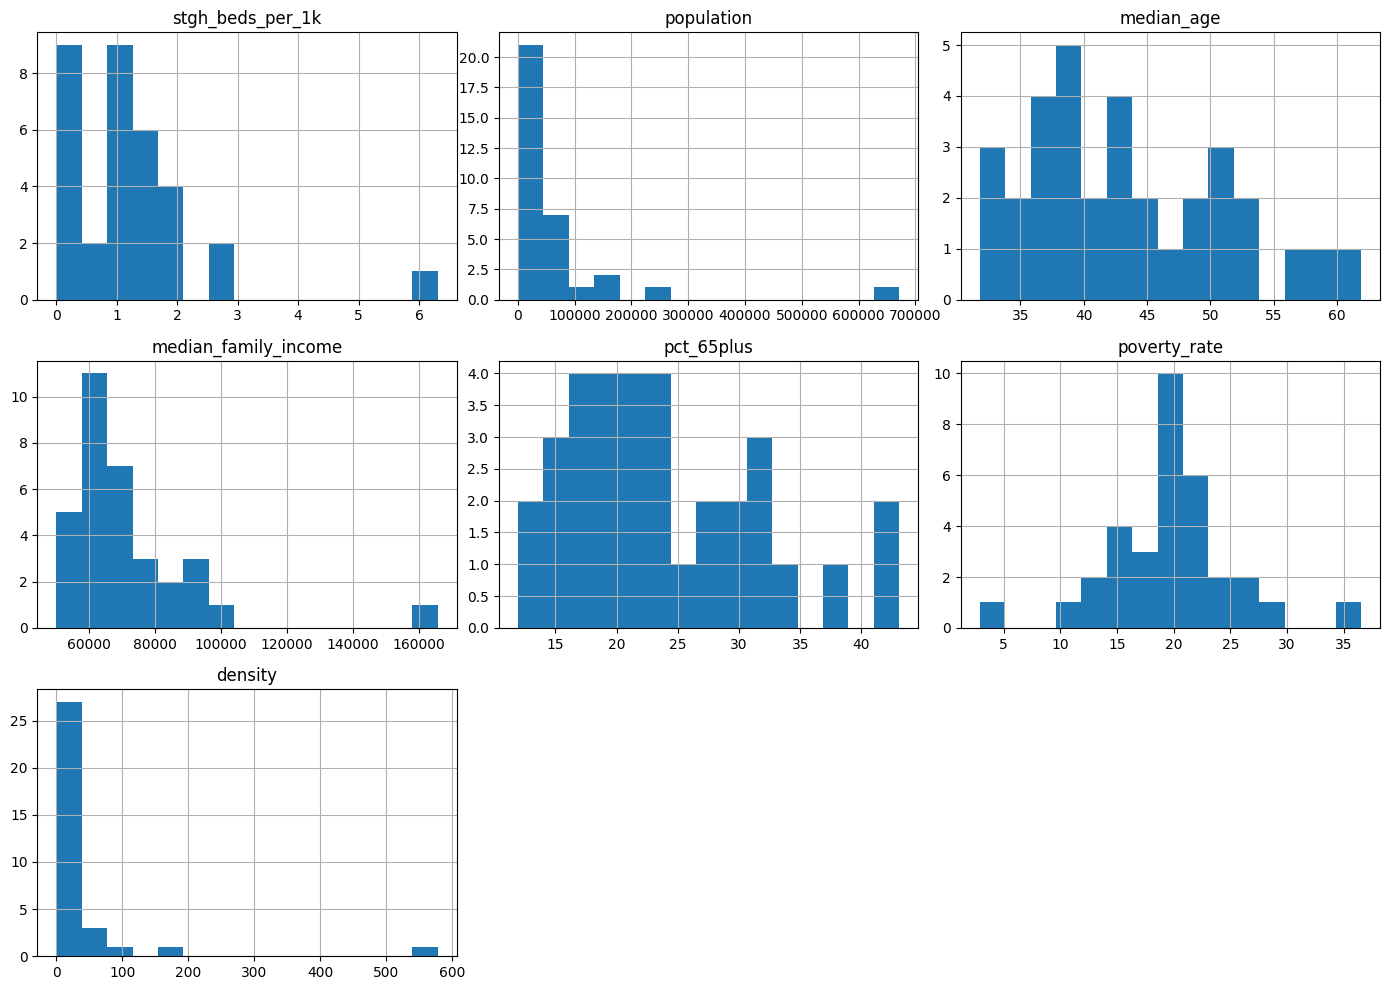

In [21]:
# --- Week 7: EDA ---
import matplotlib.pyplot as plt
model_frame = pd.read_parquet('nm_model_frame.parquet')

# Distributions of target + numeric features
num_cols = ['stgh_beds_per_1k', 'population', 'median_age',
            'median_family_income', 'pct_65plus', 'poverty_rate', 'density']

model_frame[num_cols].hist(figsize=(14, 10), bins=15)
plt.tight_layout()
plt.show()

###Correlation Matrix

The correlation matrix measures how strongly features move together, which identifies redundant predictors before modeling.

Feature decisions:

median_age vs pct_65plus — r = 0.98. Nearly the same variable measured two ways. Dropped median_age, kept pct_65plus.
population vs density — r = 0.91. Dropped population as a predictor; it remains the denominator for the per-capita measures. Kept density.
median_family_income vs poverty_rate — r = −0.78. Related but distinct; both retained, with coefficients monitored for instability.

No feature exceeds |0.29| correlation with the target. Weak linear signal is expected at n=33 with a zero-inflated target. This motivates two choices: a Dummy baseline on every model as an honesty check, and Random Forest to capture any non-linear or interaction effects that a linear model would miss.

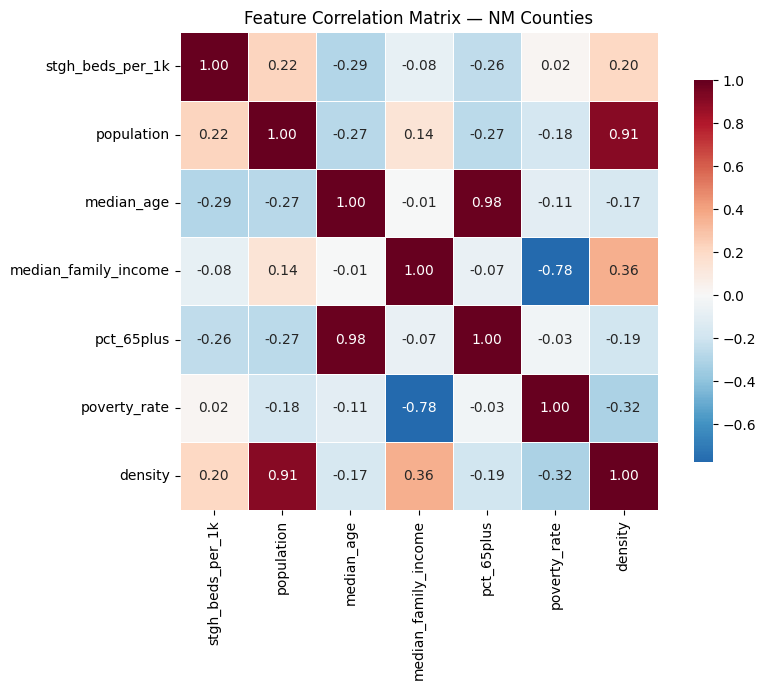

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numeric features only (drop fips/county/cbsa_ind — cbsa is categorical)
corr_cols = ['stgh_beds_per_1k', 'population', 'median_age',
             'median_family_income', 'pct_65plus', 'poverty_rate', 'density']

corr = model_frame[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix — NM Counties')
plt.tight_layout()
plt.show()

Box plot Rurality vs. bed access (boxplot finding):
- Medians nearly identical across rural/micro/metro (~1.18) — rurality alone
  does NOT linearly predict bed access.
- Rural (non-core) shows the widest, bimodal spread: cluster of zeros
  (no acute hospital) AND Union's 6.31 spike (small-denominator inflation).
- Metropolitan zeros (e.g. Sandoval) reflect the satellite-reporting artifact,
  not true absence of care.
- Micropolitan is tightest/most consistent.
- Revised implications: access gaps concentrate at population extremes and are
  obscured by reporting artifacts — a simple rural/urban split misses this,
  motivating a multivariate model.  

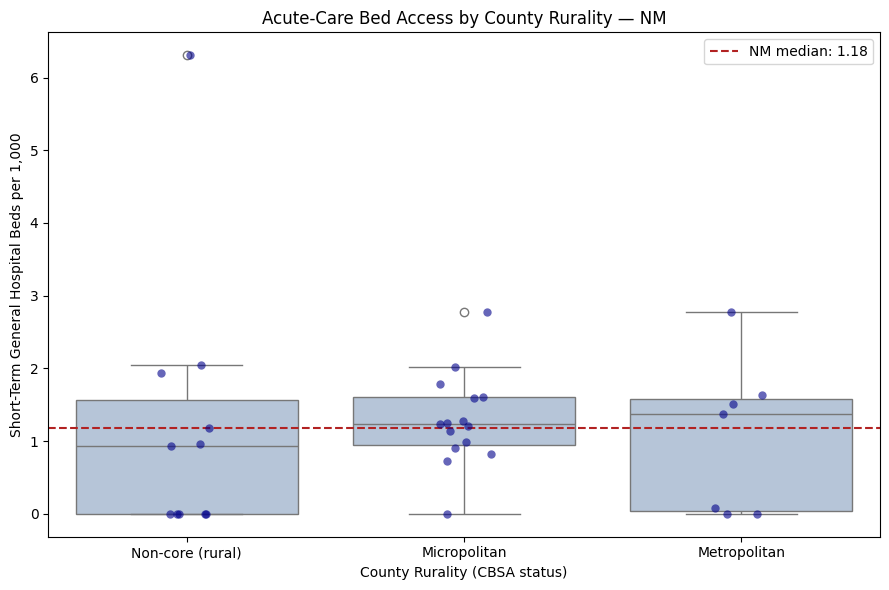

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map cbsa codes to readable labels for the plot
cbsa_labels = {0: 'Non-core (rural)', 1: 'Metropolitan', 2: 'Micropolitan'}
model_frame['rurality'] = model_frame['cbsa_ind'].map(cbsa_labels)

# Order the categories rural → micro → metro (least to most urban)
order = ['Non-core (rural)', 'Micropolitan', 'Metropolitan']

plt.figure(figsize=(9, 6))
sns.boxplot(data=model_frame, x='rurality', y='stgh_beds_per_1k',
            order=order, color='lightsteelblue')
sns.stripplot(data=model_frame, x='rurality', y='stgh_beds_per_1k',
              order=order, color='darkblue', size=6, alpha=0.6)  # show every county
plt.axhline(model_frame['stgh_beds_per_1k'].median(), color='firebrick',
            linestyle='--', label=f"NM median: {model_frame['stgh_beds_per_1k'].median():.2f}")
plt.xlabel('County Rurality (CBSA status)')
plt.ylabel('Short-Term General Hospital Beds per 1,000')
plt.title('Acute-Care Bed Access by County Rurality — NM')
plt.legend()
plt.tight_layout()
plt.show()

Density vs. beds (raw and log1p)

Raw density clusters near zero while Bernalillo at 578 dominates the axis.
log1p(density) de-clusters the points and reveals a weak positive association (r = 0.20) — denser counties trend toward more beds.
Zero-bed counties appear across the full density range, from frontier to moderate. Density alone cannot separate served from unserved, which motivates the multivariate and non-linear models that follow.

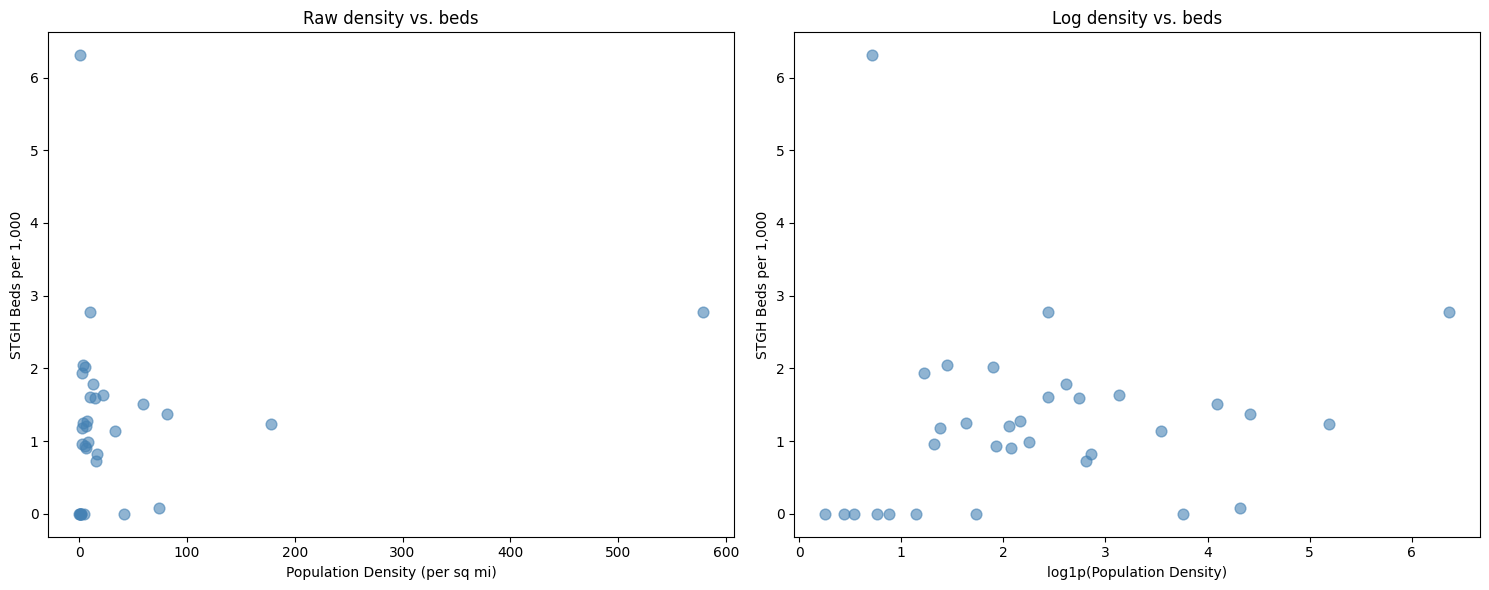

In [24]:

import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: raw density (skewed — Bernalillo will stretch the x-axis)
axes[0].scatter(model_frame['density'], model_frame['stgh_beds_per_1k'],
                alpha=0.6, s=60, color='steelblue')
axes[0].set_xlabel('Population Density (per sq mi)')
axes[0].set_ylabel('STGH Beds per 1,000')
axes[0].set_title('Raw density vs. beds')

# Right: log density (spreads the rural cluster out)
axes[1].scatter(np.log1p(model_frame['density']), model_frame['stgh_beds_per_1k'],
                alpha=0.6, s=60, color='steelblue')
axes[1].set_xlabel('log1p(Population Density)')
axes[1].set_ylabel('STGH Beds per 1,000')
axes[1].set_title('Log density vs. beds')

plt.tight_layout()
plt.show()

### BUILD DUMMY, Cross Validation and K-Fold Cross Validation


The baseline test. Before trusting any model, we check it against a model that doesn't try. DummyRegressor guesses the state average for every county — it ignores poverty, age, income, everything. If a real model can't beat that guess, it hasn't learned anything useful.

Why we test five times. With only 33 counties, testing once is luck-dependent — the score changes based on which counties you happen to test on. So we split the data five ways, test five times, and average. Every county gets tested once.

The numbers to beat:


Guessing the average (regression)	R² = −0.338
Guessing the bigger group (classification)	51.4% accurate

Scores swung widely between the five tests, which is what happens with only 6–7 counties in each. That instability affects every model here, not just this one.

Every model that follows is compared to these two numbers.

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import r2_score, accuracy_score

# --- Build X ---
X = pd.DataFrame({
    'pct_65plus':            model_frame['pct_65plus'],
    'median_family_income':  model_frame['median_family_income'],
    'poverty_rate':          model_frame['poverty_rate'],
    'log_density':           np.log1p(model_frame['density']),
})

# One-hot the categorical rurality indicator (drop_first avoids the dummy trap)
cbsa_dummies = pd.get_dummies(model_frame['cbsa_ind'], prefix='cbsa', drop_first=True)
X = pd.concat([X, cbsa_dummies], axis=1)

# --- Build both targets ---
y_reg = model_frame['stgh_beds_per_1k']                      # continuous
y_clf = (y_reg > y_reg.median()).astype(int)                 # 1 = adequate, 0 = under-provisioned
y_clf = y_clf.rename('adequate_beds')
print(X.shape, y_reg.shape)
print(X.columns.tolist())
print(y_clf.value_counts())

(33, 6) (33,)
['pct_65plus', 'median_family_income', 'poverty_rate', 'log_density', 'cbsa_1.0', 'cbsa_2.0']
adequate_beds
0    17
1    16
Name: count, dtype: int64


In [26]:
# --- Single split (interpretable) ---
Xtr, Xte, ytr_reg, yte_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
Xtr_c, Xte_c, ytr_clf, yte_clf = train_test_split(X, y_clf, test_size=0.2,
                                                  random_state=42, stratify=y_clf)

dum_reg = DummyRegressor(strategy='mean').fit(Xtr, ytr_reg)
dum_clf = DummyClassifier(strategy='most_frequent').fit(Xtr_c, ytr_clf)

print(f"Dummy Regressor  R² (single split): {r2_score(yte_reg, dum_reg.predict(Xte)):.3f}")
print(f"Dummy Classifier acc (single split): {accuracy_score(yte_clf, dum_clf.predict(Xte_c)):.3f}")

# --- 5-fold CV (trustworthy) ---
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_reg = cross_val_score(DummyRegressor(strategy='mean'), X, y_reg, cv=kf, scoring='r2')
cv_clf = cross_val_score(DummyClassifier(strategy='most_frequent'), X, y_clf, cv=skf, scoring='accuracy')

print(f"\nDummy Regressor  R² (5-fold): {cv_reg.mean():.3f}  (folds: {np.round(cv_reg, 3)})")
print(f"Dummy Classifier acc (5-fold): {cv_clf.mean():.3f}  (folds: {np.round(cv_clf, 3)})")

Dummy Regressor  R² (single split): -0.439
Dummy Classifier acc (single split): 0.571

Dummy Regressor  R² (5-fold): -0.338  (folds: [-0.439 -0.011 -0.089 -1.009 -0.143])
Dummy Classifier acc (5-fold): 0.514  (folds: [0.429 0.571 0.571 0.5   0.5  ])


### Linear Regression

Linear regression is the simplest test of the hypothesis: if need drivers predict provision, a straight-line relationship should show it. Fitted on all five features and scored with the same 5-fold cross-validation as the baseline, it returned R² = −0.857 against the Dummy's −0.338 — more than twice as far from the mark as guessing the average. The coefficients are not interpretable as effects, because a model this far below its baseline has not identified a relationship to interpret.

In [27]:
from sklearn.linear_model import LinearRegression

# --- Single split ---
lr = LinearRegression().fit(Xtr, ytr_reg)
r2_split = r2_score(yte_reg, lr.predict(Xte))

# --- 5-fold CV (same kf as Dummy) ---
cv_lr = cross_val_score(LinearRegression(), X, y_reg, cv=kf, scoring='r2')

print(f"Linear Regression R² (single split): {r2_split:.3f}   [Dummy: -0.439]")
print(f"Linear Regression R² (5-fold):       {cv_lr.mean():.3f}   [Dummy: -0.338]")
print(f"  folds: {np.round(cv_lr, 3)}")

# --- Coefficients: which need drivers move predicted capacity? ---
coefs = pd.Series(lr.coef_, index=X.columns).sort_values()
print("\nCoefficients:")
print(coefs.to_string())

Linear Regression R² (single split): -0.849   [Dummy: -0.439]
Linear Regression R² (5-fold):       -0.857   [Dummy: -0.338]
  folds: [-0.849 -0.879 -0.165 -0.72  -1.673]

Coefficients:
cbsa_1.0               -0.968572
cbsa_2.0               -0.009891
median_family_income   -0.000010
pct_65plus              0.006739
poverty_rate            0.061034
log_density             0.581007


###Residuals
The residual is the gap between a county's actual bed rate and the rate the model predicted, originally intended to flag under-provisioned counties. Because the model scores below the Dummy baseline, these residuals measure model error rather than county shortfall, and are not used to rank counties.

In [28]:
# Fit on full data to get a residual for every county
lr_full = LinearRegression().fit(X, y_reg)
model_frame['predicted_beds_per_1k'] = lr_full.predict(X)
model_frame['residual'] = model_frame['stgh_beds_per_1k'] - model_frame['predicted_beds_per_1k']

# Most under-provisioned = most negative residual
gap = model_frame[['county', 'rurality', 'stgh_beds_per_1k',
                   'predicted_beds_per_1k', 'residual']].sort_values('residual')
print(gap.to_string(index=False))

    county         rurality  stgh_beds_per_1k  predicted_beds_per_1k  residual
 Guadalupe Non-core (rural)          0.000000               1.637987 -1.637987
   Hidalgo Non-core (rural)          0.000000               1.414528 -1.414528
  Valencia     Metropolitan          0.075814               1.466985 -1.391171
     Curry     Micropolitan          1.143535               2.096146 -0.952612
      Mora     Micropolitan          0.000000               0.927915 -0.927915
  Sandoval     Metropolitan          0.000000               0.914650 -0.914650
       Lea     Micropolitan          0.818297               1.723122 -0.904825
    Cibola Non-core (rural)          0.933532               1.769797 -0.836264
    DeBaca Non-core (rural)          0.000000               0.716121 -0.716121
    Catron Non-core (rural)          0.000000               0.562866 -0.562866
      Taos     Micropolitan          0.726639               1.235919 -0.509280
      Quay Non-core (rural)          1.175088       

## Standard scaling

The features are measured in completely different units — income in tens of thousands, poverty rate in percentage points. That makes their coefficients impossible to compare: income's looks tiny (−0.00001) only because its numbers are so large.

Standard scaling puts every feature on the same footing, so the coefficients can be ranked against each other. It doesn't change what the model predicts — the score is −0.857 scaled or unscaled — it just makes the output readable.

Both still lose to the Dummy baseline at −0.338.

In [29]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline scales INSIDE each CV fold — no leakage from test into train
pipe_lr = make_pipeline(StandardScaler(), LinearRegression())

cv_lr_scaled = cross_val_score(pipe_lr, X, y_reg, cv=kf, scoring='r2')

print(f"LR scaled   R² (5-fold): {cv_lr_scaled.mean():.3f}   folds: {np.round(cv_lr_scaled, 3)}")
print(f"LR unscaled R² (5-fold): {cv_lr.mean():.3f}")
print(f"Dummy       R² (5-fold): -0.338")

# Readable coefficients — now in standard-deviation units, comparable across features
pipe_lr.fit(X, y_reg)
coefs_scaled = pd.Series(
    pipe_lr.named_steps['linearregression'].coef_, index=X.columns
).sort_values(key=abs, ascending=False)
print("\nStandardized coefficients (largest effect first):")
print(coefs_scaled.to_string())

LR scaled   R² (5-fold): -0.857   folds: [-0.849 -0.879 -0.165 -0.72  -1.673]
LR unscaled R² (5-fold): -0.857
Dummy       R² (5-fold): -0.338

Standardized coefficients (largest effect first):
cbsa_1.0               -0.730521
median_family_income   -0.592232
log_density             0.584230
cbsa_2.0               -0.396831
poverty_rate           -0.392746
pct_65plus             -0.310768


#### Reducing Features
With only 33 counties, six features may be too many — a model can start fitting noise instead of pattern. Cutting to three (density, poverty, elderly share) tests whether the extra features were hurting.

The score improved from −0.857 to −0.705, but it still loses badly to the Dummy at −0.338. Trimming features helped a little; it didn't find a signal that wasn't there.

In [30]:
X3 = X[['log_density', 'poverty_rate', 'pct_65plus']]

cv_lr3 = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                         X3, y_reg, cv=kf, scoring='r2')

print(f"LR 3-feature R² (5-fold): {cv_lr3.mean():.3f}   folds: {np.round(cv_lr3, 3)}")
print(f"LR 6-feature R² (5-fold): {cv_lr_scaled.mean():.3f}")
print(f"Dummy        R² (5-fold): -0.338")

pipe3 = make_pipeline(StandardScaler(), LinearRegression()).fit(X3, y_reg)
print("\nCoefficients:")
print(pd.Series(pipe3.named_steps['linearregression'].coef_, index=X3.columns).to_string())

LR 3-feature R² (5-fold): -0.705   folds: [-0.901 -1.238  0.21  -1.209 -0.387]
LR 6-feature R² (5-fold): -0.857
Dummy        R² (5-fold): -0.338

Coefficients:
log_density    -0.017035
poverty_rate    0.009539
pct_65plus     -0.315419


### Apply Ridge CV
Ridge tunes how much influence each feature gets, shrinking weak ones toward zero. It scored −0.425 — better than linear regression's −0.705, still below the Dummy's −0.338. Features are showing no relationship to y.

In [31]:
from sklearn.linear_model import RidgeCV

ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25)))
cv_ridge = cross_val_score(ridge, X3, y_reg, cv=kf, scoring='r2')

print(f"Ridge 3-feature R² (5-fold): {cv_ridge.mean():.3f}   folds: {np.round(cv_ridge, 3)}")
print(f"LR    3-feature R² (5-fold): {cv_lr3.mean():.3f}")
print(f"Dummy           R² (5-fold): -0.338")

Ridge 3-feature R² (5-fold): -0.425   folds: [-0.754 -0.115 -0.079 -1.003 -0.172]
LR    3-feature R² (5-fold): -0.705
Dummy           R² (5-fold): -0.338


### The three correlation types:

Positive correlation — as one goes up, the other goes up. If provision followed need, poorer counties would have more beds.
Inverse correlation — as one goes up, the other goes down. Poorer counties would have fewer beds.
Null — no consistent relationship either way. Knowing a county's poverty rate tells you nothing about its bed count.

**Null result.**

Null result. County need drivers — density, poverty rate, elderly share — do not predict acute-care bed provision in New Mexico. Every model tested (linear regression at 6 and 3 features, Ridge, Random Forest) scored below a Dummy predictor that just guesses the average (R² = −0.338). The result holds across linear, regularized, and non-linear models, so it reflects the data, not the choice of algorithm.

What it means. If capacity were allocated by measurable need, these variables would carry signal. They carry none — not a positive relationship, not an inverse one. Provision appears driven by something else: ownership and reporting structures, historical siting, institutional inertia. That is the provision-vs-need mismatch this project set out to examine.

Limitations. n = 33. The target is zero-inflated, with 8 counties at zero acute beds. Small-denominator inflation (Union) and reporting artifacts (Sandoval, Valencia) add noise.

Next. Binary classification on a median split — adequate vs. under-provisioned — to test whether a pattern emerges.

##Random Forrest

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=2)
cv_rf = cross_val_score(rf, X3, y_reg, cv=kf, scoring='r2')

print(f"Random Forest R² (5-fold): {cv_rf.mean():.3f}   folds: {np.round(cv_rf, 3)}")
print(f"Ridge         R² (5-fold): {cv_ridge.mean():.3f}")
print(f"Dummy         R² (5-fold): -0.338")

rf.fit(X3, y_reg)
print("\nFeature importances:")
print(pd.Series(rf.feature_importances_, index=X3.columns).sort_values(ascending=False).to_string())

Random Forest R² (5-fold): -0.835   folds: [-0.907 -0.839 -0.36  -0.648 -1.421]
Ridge         R² (5-fold): -0.425
Dummy         R² (5-fold): -0.338

Feature importances:
log_density     0.506645
pct_65plus      0.272229
poverty_rate    0.221126


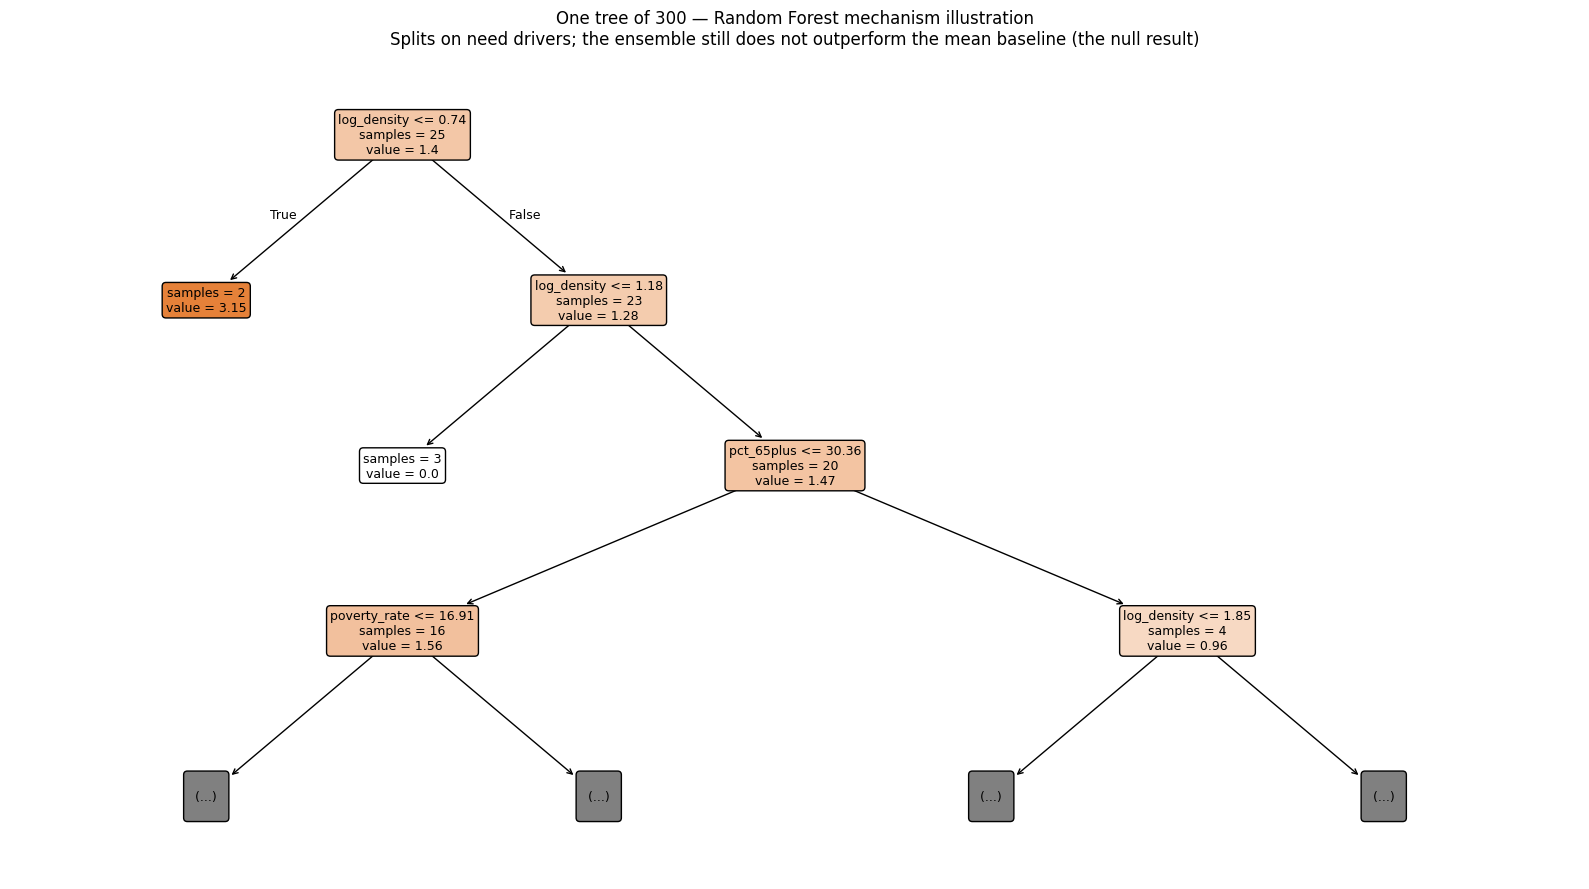

In [33]:
# Random Forest tests whether the relationship is non-linear — something a straight-line model would miss.
# It scored −0.835, worse than Ridge (−0.425) and below the Dummy (−0.338).
# The feature importances show where the forest splits,
# not what predicts provision.


import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_ix = 0                      # any of the 300; deterministic via random_state
fig, ax = plt.subplots(figsize=(16, 9))
plot_tree(
    rf.estimators_[tree_ix],
    feature_names=X3.columns.tolist(),
    filled=True, rounded=True, precision=2,
    max_depth=3, fontsize=9, impurity=False, ax=ax,
)
ax.set_title(
    f"One tree of {rf.n_estimators} — Random Forest mechanism illustration\n"
    "Splits on need drivers; the ensemble still does not outperform the "
    "mean baseline (the null result)", fontsize=12)
fig.tight_layout()
fig.savefig("rf_single_tree.png", dpi=150, bbox_inches="tight")
plt.show()

##Pooled Rural Western States

The sample size of 33 counties may be too small to carry a relationship between features and target.  We decided to compare rural counties in other states ['NM', 'MT', 'WY', 'ID', 'NV', 'UT', 'AZ', 'CO'] to determine if the target value has a relationship to our features.  The total number of counties is 248 plus the 33 counties of NM = 281.

In [34]:
west = ['NM', 'MT', 'WY', 'ID', 'NV', 'UT', 'AZ', 'CO']

pooled = df[df['st_name_abbrev'].isin(west)].copy()

pooled_frame = pd.DataFrame({
    'fips':       pooled['fips_st_cnty'].astype(str).str.zfill(5),
    'county':     pooled['cnty_name'],
    'state':      pooled['st_name_abbrev'],
    'population': pooled['popn_est_23'],
    'cbsa_ind':   pooled['cbsa_ind_23'],
    'stgh_beds_per_1k': pooled['stgh_hosp_beds_23'] / pooled['popn_est_23'] * 1000,
})
pooled_frame['pct_65plus']   = pooled['popn_est_ge65_23'] / pooled['popn_est_23'] * 100
pooled_frame['poverty_rate'] = (pooled['popn_incpovlt50_23'] + pooled['popn_incpov_50_99_23']) \
                                / pooled['popn_est_23'] * 100
pooled_frame['density']      = pooled['popn_est_23'] / pooled['land_area_mi2_20']

print(pooled_frame.shape)
print(pooled_frame['state'].value_counts())
print("\nNAs:\n", pooled_frame.isna().sum())

(281, 9)
state
CO    64
MT    56
ID    44
NM    33
UT    29
WY    23
NV    17
AZ    15
Name: count, dtype: int64

NAs:
 fips                0
county              0
state               0
population          0
cbsa_ind            0
stgh_beds_per_1k    0
pct_65plus          0
poverty_rate        0
density             0
dtype: int64


### Note
States with more counties will be overrepresented in the model.  So, we log1p to make the county distribution more balanced.  Linear and Ridge edge past the Dummy on individual folds, but a single fold (R² = −0.789 and −0.626 against the Dummy's −0.311) erases those gains. Beating a baseline on some folds and collapsing on others is instability, not predictive power — which is what motivates the population floor applied next.

In [35]:
# Build X and y on the pooled frame
Xp = pd.DataFrame({
    'log_density':  np.log1p(pooled_frame['density']),
    'poverty_rate': pooled_frame['poverty_rate'],
    'pct_65plus':   pooled_frame['pct_65plus'],
})
yp = pooled_frame['stgh_beds_per_1k']

kfp = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Dummy (mean)':   DummyRegressor(strategy='mean'),
    'Linear':         make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge':          make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25))),
    'Random Forest':  RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=2),
}

print(f"Pooled: {len(yp)} counties across {pooled_frame['state'].nunique()} states\n")
for name, m in models.items():
    s = cross_val_score(m, Xp, yp, cv=kfp, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

Pooled: 281 counties across 8 states

Dummy (mean)    R² =  -0.074   folds: [-0.045 -0.005 -0.311 -0.001 -0.009]
Linear          R² =  -0.140   folds: [ 0.029 -0.028 -0.789  0.069  0.018]
Ridge           R² =  -0.104   folds: [ 0.008 -0.01  -0.626  0.069  0.037]
Random Forest   R² =  -0.566   folds: [-0.111 -0.185 -2.295 -0.052 -0.187]


### Counties with highest bed counts
Eight counties in rural states have mean of 2.826 beds per 1,000 thousand residents.

In [36]:
print(yp.describe())
print("\nTop 10 highest beds per 1k:")
print(pooled_frame.nlargest(10, 'stgh_beds_per_1k')[
    ['county', 'state', 'population', 'stgh_beds_per_1k']].to_string(index=False))

count    281.000000
mean       2.826459
std        4.207422
min        0.000000
25%        0.627549
50%        1.612091
75%        2.768994
max       29.143106
Name: stgh_beds_per_1k, dtype: float64

Top 10 highest beds per 1k:
  county state  population  stgh_beds_per_1k
Sedgwick    CO      2299.0         29.143106
Garfield    MT      1211.0         26.424443
    Baca    CO      3344.0         23.624402
Huerfano    CO      7055.0         19.844082
 Prairie    MT      1112.0         19.784173
   Kiowa    CO      1384.0         18.063584
  Carter    MT      1418.0         17.630465
   Butte    ID      2758.0         15.591008
 Daniels    MT      1633.0         15.309247
Big Horn    WY     12018.0         12.980529


Minimum population threshold and Winsorze the target 95th percentile - Whatever determines hospital bed placement in the rural West, it isn't a function of population need, linear or otherwise.

---
Pooled multi-state test (8 Western states, 281 counties; 225 after applying a
5,000-population floor):
- Declared rule: counties under 5,000 residents excluded — per-capita rates are
  unstable at small denominators (Sedgwick County, CO: 2,299 residents, 29.1
  beds/1k from a single facility). Applied once, before model comparison; both
  filtered and unfiltered results reported.
- Filtering removed the fold instability seen in NM (fold R² range narrowed from
  [-1.0, -0.01] to [-0.023, -0.006] for the baseline).
- Results: Ridge R² = 0.009, Linear = -0.001, Random Forest = -0.035,
  Dummy = -0.013. Ridge marginally clears baseline; no model demonstrates
  meaningful predictive power.
- Conclusion: the NM null result is NOT an artifact of small sample size. Need
  drivers do not predict acute-bed provision across the rural West.

In [37]:
# Declared rule: exclude counties below 5,000 residents — per-capita rates are
# unstable at small denominators (a single 25-bed facility yields >20 beds/1k).
POP_FLOOR = 5000

filtered = pooled_frame[pooled_frame['population'] >= POP_FLOOR].copy()
print(f"Retained {len(filtered)} of {len(pooled_frame)} counties "
      f"(dropped {len(pooled_frame) - len(filtered)} below {POP_FLOOR:,})")
print(filtered['stgh_beds_per_1k'].describe())

Xf = pd.DataFrame({
    'log_density':  np.log1p(filtered['density']),
    'poverty_rate': filtered['poverty_rate'],
    'pct_65plus':   filtered['pct_65plus'],
})
yf = filtered['stgh_beds_per_1k']

print()
for name, m in models.items():
    s = cross_val_score(m, Xf, yf, cv=kfp, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

Retained 225 of 281 counties (dropped 56 below 5,000)
count    225.000000
mean       2.297409
std        2.558707
min        0.000000
25%        0.994160
50%        1.692650
75%        2.570554
max       19.844082
Name: stgh_beds_per_1k, dtype: float64

Dummy (mean)    R² =  -0.013   folds: [-0.009 -0.017 -0.006 -0.023 -0.009]
Linear          R² =  -0.001   folds: [-0.107 -0.022  0.048  0.063  0.013]
Ridge           R² =   0.009   folds: [-0.042 -0.01   0.034  0.054  0.01 ]
Random Forest   R² =  -0.035   folds: [-0.038 -0.018  0.014 -0.106 -0.024]


### New Mexico 5,000 Floor

Applying the same 5,000 floor to New Mexico alone retains 26 of 33 counties, dropping Catron, DeBaca, Guadalupe, Harding, Hidalgo, Mora, and Union. Two zero-bed counties remain. Every model still loses to the Dummy. The null holds in New Mexico with or without the smallest counties.

In [38]:
nm_filtered = pooled_frame[(pooled_frame['state'] == 'NM') &
                           (pooled_frame['population'] >= POP_FLOOR)].copy()

print(f"NM retained {len(nm_filtered)} of 33 counties")
print("Dropped:", sorted(set(pooled_frame[pooled_frame['state']=='NM']['county'])
                         - set(nm_filtered['county'])))
print(f"Zero-bed counties remaining: {(nm_filtered['stgh_beds_per_1k'] == 0).sum()}")

Xnm = pd.DataFrame({
    'log_density':  np.log1p(nm_filtered['density']),
    'poverty_rate': nm_filtered['poverty_rate'],
    'pct_65plus':   nm_filtered['pct_65plus'],
})
ynm = nm_filtered['stgh_beds_per_1k']

print()
for name, m in models.items():
    s = cross_val_score(m, Xnm, ynm, cv=kf, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

NM retained 26 of 33 counties
Dropped: ['Catron', 'DeBaca', 'Guadalupe', 'Harding', 'Hidalgo', 'Mora', 'Union']
Zero-bed counties remaining: 2

Dummy (mean)    R² =  -0.118   folds: [-0.032 -0.135 -0.146 -0.197 -0.081]
Linear          R² =  -0.875   folds: [-1.252 -0.194 -1.264 -0.631 -1.036]
Ridge           R² =  -0.204   folds: [-0.431 -0.133 -0.142 -0.231 -0.082]
Random Forest   R² =  -0.561   folds: [-0.669 -0.008 -0.746 -0.553 -0.829]


***
Note for change County-level need — measured by population density, poverty rate, and elderly share — does not predict acute-care bed provision across 225 counties in eight Western states. The relationship is absent across linear, regularized, and non-linear models, and does not emerge with more data. This is consistent with provision being determined by factors other than measurable population need, though county-level analysis cannot rule out that hospitals serve multi-county regions in ways this geography obscures.

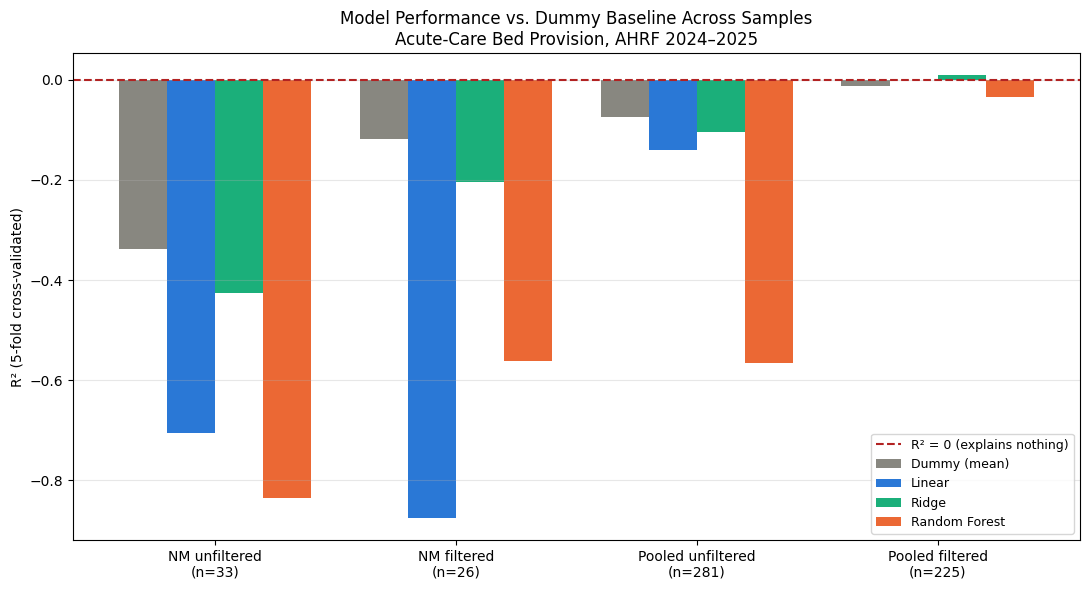

In [39]:
import matplotlib.pyplot as plt
import numpy as np

configs = ['NM unfiltered\n(n=33)', 'NM filtered\n(n=26)',
           'Pooled unfiltered\n(n=281)', 'Pooled filtered\n(n=225)']
results = {
    'Dummy (mean)':  [-0.338, -0.118, -0.074, -0.013],
    'Linear':        [-0.705, -0.875, -0.140, -0.001],
    'Ridge':         [-0.425, -0.204, -0.104,  0.009],
    'Random Forest': [-0.835, -0.561, -0.566, -0.035],
}

x = np.arange(len(configs))
width = 0.2
colors = ['#888780', '#2a78d6', '#1baf7a', '#eb6834']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (name, vals) in enumerate(results.items()):
    ax.bar(x + (i - 1.5) * width, vals, width, label=name, color=colors[i])

ax.axhline(0, color='firebrick', linestyle='--', linewidth=1.5,
           label='R² = 0 (explains nothing)')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.set_ylabel('R² (5-fold cross-validated)')
ax.set_title('Model Performance vs. Dummy Baseline Across Samples\nAcute-Care Bed Provision, AHRF 2024–2025')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation Matrix
yo identify true psotitive and true negeative, sensitivity is the true positive rate to actual postive TP / (TP + FN) [Sensitivity Definition](https://www.datacamp.com/tutorial/sensitivity-specificity-complete-guide)is a recall method measuring corect possitives.   Sensitivity/recall = TP/(TP+FN) (classifiers only, confusion-matrix territory)

## GNB Modeling and Sensitivity (Recall)
Gaussian Naive Bayes tests whether a coarser target retains signal the continuous one lost — instead of predicting the exact bed rate, it classifies counties as adequate or under-provisioned on a median split.

Sensitivity (recall). For classification, accuracy alone can mislead. Sensitivity measures how many of the actually under-provisioned counties the model correctly identified: TP / (TP + FN). A model that labels everything "adequate" scores well on accuracy and zero on sensitivity — it misses every county that needs attention.

In [40]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

gnb = make_pipeline(StandardScaler(), GaussianNB())
cv_gnb = cross_val_score(gnb, X3, y_clf, cv=skf, scoring='accuracy')

print(f"GaussianNB accuracy (5-fold): {cv_gnb.mean():.3f}   folds: {np.round(cv_gnb, 3)}")
print(f"Dummy      accuracy (5-fold): 0.514")

# Single split for the confusion matrix
gnb_split = make_pipeline(StandardScaler(), GaussianNB()).fit(Xtr_c[X3.columns], ytr_clf)
pred = gnb_split.predict(Xte_c[X3.columns])

print(f"\nSingle-split accuracy: {accuracy_score(yte_clf, pred):.3f}")
print("\nConfusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(yte_clf, pred))
print("\n", classification_report(yte_clf, pred,
      target_names=['under-provisioned', 'adequate'], zero_division=0))

GaussianNB accuracy (5-fold): 0.462   folds: [0.429 0.286 0.429 0.5   0.667]
Dummy      accuracy (5-fold): 0.514

Single-split accuracy: 0.714

Confusion matrix (rows=actual, cols=predicted):
[[3 1]
 [1 2]]

                    precision    recall  f1-score   support

under-provisioned       0.75      0.75      0.75         4
         adequate       0.67      0.67      0.67         3

         accuracy                           0.71         7
        macro avg       0.71      0.71      0.71         7
     weighted avg       0.71      0.71      0.71         7



###Leave-one-state-out validation

K-fold splits counties randomly, so a model can train on some counties and test on similar ones. Leave-one-state-out is stricter: train on seven states, test on the eighth, rotating through all eight. It asks whether patterns learned elsewhere transfer to a state the model has never seen.

A model trained on the other seven states treats New Mexico as though it were provisioned like them — and over-predicts its capacity by roughly 87%. The prediction error is the finding: New Mexico is not a typical rural Western state. It records the lowest mean (1.30) and median (1.24) acute beds per 1,000 of the eight, against Montana's 3.97/3.22 and Wyoming's 3.58/2.39



In [41]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score

logo = LeaveOneGroupOut()
groups = filtered['state']

print(f"Leave-one-state-out ({groups.nunique()} states, {len(filtered)} counties)\n")
for name, m in models.items():
    s = cross_val_score(m, Xf, yf, cv=logo, groups=groups, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}")
    for st, sc in zip(sorted(groups.unique()), s):
        print(f"    {st}: {sc:>7.3f}")
    print()

Leave-one-state-out (8 states, 225 counties)

Dummy (mean)    R² =  -0.561
    AZ:  -0.746
    CO:  -0.014
    ID:  -0.253
    MT:  -0.424
    NM:  -2.673
    NV:  -0.007
    UT:  -0.159
    WY:  -0.212

Linear          R² =  -1.463
    AZ:  -1.187
    CO:   0.045
    ID:  -0.256
    MT:  -0.344
    NM:  -9.536
    NV:  -0.072
    UT:  -0.182
    WY:  -0.171

Ridge           R² =  -1.210
    AZ:  -0.953
    CO:   0.043
    ID:  -0.224
    MT:  -0.374
    NM:  -7.871
    NV:  -0.028
    UT:  -0.088
    WY:  -0.185

Random Forest   R² =  -1.402
    AZ:  -0.886
    CO:   0.117
    ID:  -1.090
    MT:  -0.161
    NM:  -8.633
    NV:  -0.014
    UT:  -0.562
    WY:   0.010



### Leave-one-state-out findings

1. The null holds across the region. No model exceeds R² = 0.12 in any state; Colorado is the ceiling at +0.045 (Ridge). Need drivers do not predict acute-bed provision anywhere in the rural West.

2. New Mexico is an outlier. Its LOSO scores (Dummy −2.673, Ridge −7.871) are an order of magnitude worse than any other state, all of which fall between −1.2 and +0.1. Because even the mean predictor fails this badly, the cause isn't model error — New Mexico's provision is systematically below the regional average.

This holds despite the 5,000-population floor having removed seven of New Mexico's smallest counties, several with zero acute beds. Caveat: LOSO places all 26 remaining NM counties in a single test fold, so the magnitude of the gap is the finding, not the precise coefficient.

###Provision by state

Mean and median acute-care beds per 1,000 residents across the eight pooled states, sorted lowest to highest.

In [90]:
print(filtered.groupby('state')['stgh_beds_per_1k']
      .agg(['count', 'mean', 'median']).round(2)
      .sort_values('mean', ascending=True))

       count  mean  median
state                     
NM        26  1.30    1.24
AZ        15  1.62    1.90
ID        37  1.67    1.50
UT        25  1.77    1.48
CO        52  2.01    1.43
NV        12  2.16    1.54
WY        21  3.58    2.39
MT        37  3.97    3.22


### New Mexico is last on both mean and median.

Note also that its two figures nearly coincide (1.30 and 1.24), while Colorado's diverge (2.01 versus 1.43) — the low provision in New Mexico is broad, not the result of a few extreme counties.

#Facility Coordinates and CMS Validation Layer


The modeling used AHRF bed counts, which are county aggregates with no locations attached. To measure distance to care, the analysis needs the facilities themselves. This queries the HRSA GIS service for CMS-approved facilities in New Mexico, returning names, categories, bed counts, and coordinates.

In [43]:
# --- CMS acute-care facility coordinates (HRSA GIS / CMS Provider of Services) ---
import requests
import geopandas as gpd

BASE = ("https://gisportal.hrsa.gov/server/rest/services/"
        "HealthCareFacilities/CMSApprovedFacilities_FS/MapServer")

q = requests.get(f"{BASE}/0/query", params={
    "where": "CMS_PROVIDER_STATE_ABBR='NM'",
    "outFields": ("FACILITY_NM,CMS_PROVIDER_CITY,CMS_PROVIDER_CAT_SUB_TYP_DESC,"
                  "CERTIFIED_BED_CT,TOT_BED_CT"),
    "returnGeometry": "true", "outSR": "4326", "f": "json",
}, timeout=60).json()

nm_hosp = pd.DataFrame([{**f['attributes'],
                         'lon': f['geometry']['x'],
                         'lat': f['geometry']['y']} for f in q['features']])
print(f"{len(nm_hosp)} NM facilities retrieved")
print(nm_hosp['CMS_PROVIDER_CAT_SUB_TYP_DESC'].value_counts().to_string())

71 NM facilities retrieved
CMS_PROVIDER_CAT_SUB_TYP_DESC
Short Term                   26
Data not provided by CMS     16
Critical Access Hospitals    13
Rehabilitation                5
Psychiatric                   5
Long Term                     3
Transplant Hospitals          2
Rural Emergency Hospital      1


### Results

71 facilities returned across eight categories. Only three qualify as acute care for this analysis — Short Term (26), Critical Access Hospitals (13), and Rural Emergency Hospital (1) — for 40 facilities total. Rehabilitation, psychiatric, long-term, and transplant facilities are excluded: they provide real care, but not the emergency and general care this project measures.

Note the 16 facilities marked "Data not provided by CMS." These are excluded by the same filter, so any acute-care facility among them is invisible to the distance layer.

## Spatial Join
AHRF county aggregates and CMS facility-level sums measure the same quantity through different pipelines — different agency, different methodology, different reporting path. Merging them on FIPS and differencing the per-1,000 rates shows where the two sources disagree, and those disagreements are where reporting artifacts surface.

In [44]:
# --- Filter to acute care, spatial join to counties, aggregate beds ---
acute_types = ['Short Term', 'Critical Access Hospitals', 'Rural Emergency Hospital']
acute = nm_hosp[nm_hosp['CMS_PROVIDER_CAT_SUB_TYP_DESC'].isin(acute_types)].copy()

acute_geo = gpd.GeoDataFrame(
    acute, geometry=gpd.points_from_xy(acute['lon'], acute['lat']), crs="EPSG:4326")

counties = gpd.read_file(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json")
nm_counties = counties[counties['id'].str.startswith('35')].copy()

joined = gpd.sjoin(acute_geo, nm_counties, how='left', predicate='within')

cms_beds = (joined.groupby('id')
            .agg(cms_facilities=('FACILITY_NM','count'), cms_beds=('TOT_BED_CT','sum'))
            .reset_index().rename(columns={'id':'fips'}))

print(f"{len(acute)} acute facilities | unassigned: {joined['id'].isna().sum()} | "
      f"counties with beds: {len(cms_beds)}")

40 acute facilities | unassigned: 0 | counties with beds: 25


The 40 acute-care facilities are placed on a map by coordinate and joined to county polygons, then bed counts are summed per county. All 40 fall inside a New Mexico county — no unassigned facilities, which confirms the coordinates are valid.

25 of 33 counties have acute-care beds by this measure, leaving 8 without — the same count AHRF reports, from an entirely separate source.

### AHRF vs. CMS bed counts

AHRF county aggregates and CMS facility sums measure the same quantity through different pipelines — different agency, different methodology, different reporting path. Merging on FIPS and differencing the per-1,000 rates shows where the two disagree, and the disagreements are where reporting artifacts surface.

In [45]:
compare = model_frame[['fips','county','population','stgh_beds_per_1k']].merge(
    cms_beds, on='fips', how='left')
compare[['cms_facilities','cms_beds']] = compare[['cms_facilities','cms_beds']].fillna(0)
compare['cms_beds_per_1k'] = compare['cms_beds'] / compare['population'] * 1000
compare['diff'] = compare['cms_beds_per_1k'] - compare['stgh_beds_per_1k']

print(compare[['county','stgh_beds_per_1k','cms_beds_per_1k','cms_facilities','diff']]
      .sort_values('diff', key=abs, ascending=False).to_string(index=False))

    county  stgh_beds_per_1k  cms_beds_per_1k  cms_facilities      diff
 Guadalupe          0.000000         2.795899             1.0  2.795899
      Quay          1.175088         2.937720             1.0  1.762632
Los Alamos          1.234314         2.725777             1.0  1.491463
  McKinley          1.787869         2.936175             4.0  1.148306
      Eddy          1.592700         2.737453             2.0  1.144753
     Curry          1.143535         2.244716             1.0  1.101182
  San Juan          1.640771         2.560597             2.0  0.919826
Rio Arriba          1.203732         2.006219             1.0  0.802488
  Dona Ana          1.509702         2.220150             3.0  0.710448
       Lea          0.818297         1.511768             2.0  0.693472
  Santa Fe          1.378594         1.949268             3.0  0.570674
   Socorro          1.941991         1.503477             1.0 -0.438514
Bernalillo          2.775519         2.410711             5.0 -0

###he diff column is CMS minus AHRF, sorted by magnitude. Three patterns appear.

Exact agreement — 16 counties. Luna, Lincoln, Grant, Cibola, Chaves, Colfax, Roosevelt, Taos, Union and the zero-bed counties all match to the decimal. Two independently built pipelines landing on identical rates validates both.

CMS higher than AHRF. Guadalupe is the largest gap: AHRF reports 0.00, CMS reports 2.80. The explanation is a designation change — Guadalupe County Hospital in Santa Rosa converted to a Rural Emergency Hospital (CCN 320779), the only REH in New Mexico. An REH provides emergency and outpatient care and holds no inpatient acute beds by design, so AHRF correctly reports zero short-term general beds while the CMS acute filter correctly counts the facility. Neither source is wrong; they measure different things. Quay, Los Alamos, and McKinley follow a similar classification pattern.

Agreement is not proof of accuracy. Sandoval reads 0.000 in both columns — the sources agree, and both are wrong. UNM Sandoval Regional Medical Center and Presbyterian Rust Medical Center operate under Albuquerque parent-system certifications, so their beds count toward Bernalillo in both pipelines. Two sources sharing an upstream cause can be mistaken together, which is why the next section applies manual corrections rather than relying on cross-validation alone.


### Cross-Validation of the Target Against CMS Facility Data

The AHRF-derived target (`stgh_beds_per_1k`) is validated against an
independently constructed measure. CMS acute-care facilities — subtypes Short
Term, Critical Access Hospital, and Rural Emergency Hospital — are spatially
joined to county polygons by point-in-polygon, and their bed counts are
aggregated to produce `cms_beds_per_1k` for each county. The two measures are
merged on county FIPS and differenced.

Sixteen of 33 counties agree to six decimal places, confirming that both
sources draw on the same underlying facility records and that the spatial join
assigned every facility correctly (zero unassigned). The exact matches include
Union, Taos, Colfax, Cibola, Grant, Lincoln, and Luna — all Critical Access
Hospital counties — which establishes that AHRF's `stgh_hosp_beds_23` includes
CAH beds rather than excluding them.

The disagreements fall into three interpretable patterns rather than random
noise:

- **Rural Emergency Hospital designation.** Guadalupe County shows the largest
  divergence (+2.80 beds/1k). Guadalupe County Hospital operates as a Rural
  Emergency Hospital, a federal designation available in 2023 that AHRF's 2023
  hospital categories do not yet capture. This is definitional lag, not error —
  and it revises the county that ranked worst in the residual analysis.
- **Tribal and IHS facilities.** McKinley (+1.15) and San Juan (+0.92), the
  counties with the largest Native populations, are where CMS captures Indian
  Health Service facilities that AHRF partially misses. This quantifies a
  limitation previously noted only qualitatively.
- **Bed-definition differences.** Quay (+1.76), Los Alamos (+1.49), Eddy,
  Curry, and Rio Arriba show CMS bed counts exceeding AHRF's, consistent with
  CMS `TOT_BED_CT` reporting licensed capacity where AHRF reports staffed or
  set-up beds.

Valencia County inverts the pattern: AHRF records beds where CMS lists no acute
facility, a second case of the reporting artifact documented for Sandoval, where both sources agree at zero because both inherit the same parent-system certification.

The full model suite was re-run on the CMS-derived target. Results are
consistent with the AHRF target — Dummy R² = -0.580 outperforms Ridge (-0.653),
Linear Regression (-0.881), and Random Forest (-1.225) — establishing that the
null result is not an artifact of how AHRF classifies hospital types.

In [46]:
cms_frame = compare.merge(model_frame[['fips','pct_65plus','poverty_rate','density']], on='fips')
Xc = pd.DataFrame({
    'log_density':  np.log1p(cms_frame['density']),
    'poverty_rate': cms_frame['poverty_rate'],
    'pct_65plus':   cms_frame['pct_65plus'],
})
yc = cms_frame['cms_beds_per_1k']

print("Target: CMS-derived beds per 1k (n=33)\n")
for name, m in models.items():
    s = cross_val_score(m, Xc, yc, cv=kf, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

Target: CMS-derived beds per 1k (n=33)

Dummy (mean)    R² =  -0.580   folds: [-0.757 -0.    -0.259 -1.837 -0.05 ]
Linear          R² =  -0.881   folds: [-1.195 -0.975  0.494 -2.367 -0.364]
Ridge           R² =  -0.653   folds: [-0.94  -0.054 -0.231 -1.786 -0.256]
Random Forest   R² =  -1.225   folds: [-1.32  -1.976 -0.257 -1.47  -1.099]



### Distance to Nearest Acute-Care Facility

County centroids are computed in EPSG:32613 (UTM Zone 13N, meters) rather than
in unprojected lat/lon, because centroids calculated on geographic coordinates
are geometrically distorted; the resulting points are converted back to
EPSG:4326 for distance calculation. For each of New Mexico's 33 counties, the
geodesic distance from the county centroid to every acute-care facility in the
state is computed using `geopy.distance.geodesic`, and the minimum is retained.
Facilities in neighboring counties are included, which is the point of the
measure: a county with no hospital of its own is not necessarily without
access, and a county with a hospital just across its border may be better
served than its own bed count suggests.

This variable operationalizes the access question the problem statement opens
with — residents traveling hours to reach the nearest health center — which
county-level bed counts alone cannot express. It also tests an alternative
explanation for the null result found in modeling: that provision does track
need, but at a regional rather than county geography.

Limitation: the county centroid is a coarse proxy for where residents actually
live. In large, sparsely populated counties the centroid may fall in
uninhabited terrain — Catron County's centroid lies well away from Reserve,
its population center — so distances for those counties describe geography
more than lived travel burden. A population-weighted centroid would be the
stronger measure and is noted as future work.

Distance also inherits the point-layer's completeness: a facility absent from the CMS layer cannot be measured against, which is why the Rio Rancho hospitals were added manually with verified coordinates before this calculation.

### Manual corrections.
Two Rio Rancho hospitals are absent from the CMS facility layer: UNM Sandoval Regional Medical Center (65 beds, 24/7 emergency) and Presbyterian Rust Medical Center. Both are full acute-care hospitals; neither appears as standalone because both operate under Albuquerque parent-system certifications. Coordinates were verified from health-system sources, bringing the point layer to 42 facilities.

In [47]:
# --- Manual corrections: satellite campuses missing from the CMS facility layer ---
# Both operate under a parent system's CMS certification and therefore do not
# appear as standalone facilities, despite being full acute-care hospitals with
# 24/7 emergency departments. Verified from health-system sources, Aug 2026.

CMS_FAC_PTS = list(zip(acute_geo.geometry.y, acute_geo.geometry.x))   # CMS-derived set, rebuilt from source

MISSING_ACUTE = [
    # (name, lat, lon, beds, source)
    ("UNM Sandoval Regional Medical Center (Rio Rancho)", 35.3088, -106.6798, 65,
     "unmhealth.org — 'A Campus of UNM Hospital', 65 beds, 24/7 ER"),
    ("Presbyterian Rust Medical Center (Rio Rancho)",     35.2195565 , -106.6928420, None,
     "Presbyterian Healthcare Services — operates under parent certification"),
]
fac_pts = CMS_FAC_PTS + [(lat, lon) for _, lat, lon, _, _ in MISSING_ACUTE]
print(f"Acute-care facility points: {len(fac_pts)} "
      f"({len(CMS_FAC_PTS)} CMS + {len(MISSING_ACUTE)} manual)")


Acute-care facility points: 42 (40 CMS + 2 manual)


In [ ]:
from geopy.distance import geodesic

# County centroids (projected CRS for accurate centroids, then back to lat/lon)
nm_proj = nm_counties.to_crs("EPSG:32613")
nm_counties['centroid'] = nm_proj.centroid.to_crs("EPSG:4326")




def nearest_facility(pt):
    d = [geodesic((pt.y, pt.x), f).miles for f in fac_pts]
    return min(d)

nm_counties['miles_to_nearest_acute'] = nm_counties['centroid'].apply(nearest_facility)

dist = (nm_counties[['id','miles_to_nearest_acute']]
        .rename(columns={'id':'fips'})
        .merge(model_frame[['fips','county','stgh_beds_per_1k']], on='fips')
        .sort_values('miles_to_nearest_acute', ascending=False))
print(dist.to_string(index=False))

In [49]:
from geopy.distance import geodesic
sandoval_centroid = nm_counties[nm_counties['id']=='35043']['centroid'].iloc[0]
pt = (sandoval_centroid.y, sandoval_centroid.x)

for name, lat, lon, beds, src in MISSING_ACUTE:
    print(f"{geodesic(pt, (lat, lon)).miles:6.1f} mi  {name}")

  28.2 mi  UNM Sandoval Regional Medical Center (Rio Rancho)
  33.8 mi  Presbyterian Rust Medical Center (Rio Rancho)


# Sandoval County verification

The correction matters concretely. Before it, Sandoval's centroid measured 28.2 miles to the nearest acute-care facility — a figure produced by two hospitals inside the county being invisible to the layer. Both are within 34 miles of the centroid and within a few miles of where nearly all Sandoval residents actually live.

In [50]:
#print(cand[cand['fips']=='35043'][['NAME','miles_to_acute','miles_to_outpatient']].to_string(index=False))

The distance ranking separates two kinds of zero-bed county that looked identical before.

The four worst-access counties — Catron (77.5), Hidalgo (60.5), Torrance (53.4), Harding (48.6) — are all zero-bed counties.

---
But two rows complicate the simple story, and both are worth a sentence:
Rio Arriba: 48 miles despite 1.2 beds/1k. It has a hospital (Presbyterian Española), but the county is large and the centroid sits far from it. This is the centroid limitation showing up as signal — the number reflects the county's geographic sprawl, not that residents lack a hospital.

Sandoval: 33.5 miles. With Rust Medical Center invisible to the data (your confirmed artifact), the nearest recorded acute facility is 33 miles away — but a Rio Rancho resident is minutes from Rust. The distance inherits the reporting artifact.



In [51]:
# Add distance to the feature set and re-test
model_frame = model_frame.merge(
    dist[['fips','miles_to_nearest_acute']], on='fips', how='left')

Xd = pd.DataFrame({
    'log_density':   np.log1p(model_frame['density']),
    'poverty_rate':  model_frame['poverty_rate'],
    'pct_65plus':    model_frame['pct_65plus'],
    'miles_to_acute': model_frame['miles_to_nearest_acute'],
})
yd = model_frame['stgh_beds_per_1k']

print("With distance feature (n=33)\n")
for name, m in models.items():
    s = cross_val_score(m, Xd, yd, cv=kf, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

With distance feature (n=33)

Dummy (mean)    R² =  -0.338   folds: [-0.439 -0.011 -0.089 -1.009 -0.143]
Linear          R² =  -0.452   folds: [-0.567 -0.824  0.441 -0.353 -0.956]
Ridge           R² =  -0.226   folds: [-0.451 -0.052  0.277 -0.645 -0.258]
Random Forest   R² =  -0.437   folds: [-0.582  0.163 -0.366 -0.178 -1.219]


#### Result
Adding distance as a feature did not change the outcome — Ridge −0.226 against a Dummy of −0.338

###Access map
Counties shaded by distance from centroid to nearest acute-care facility; black markers show facility locations. Dark counties with no interior marker — Catron at 77.5 miles is the extreme — are the acute-care deserts. Distance is measured from the county centroid, a coarse proxy in large counties where residents may cluster far from the geographic center. Facility markers include the two Rio Rancho hospitals added manually; without them Sandoval would appear as a desert.

In [92]:
import plotly.express as px

# nm_counties already has miles_to_nearest_acute from the distance cell;
# just attach county name + beds for hover
nm_map = nm_counties.merge(
    dist[['fips','county','stgh_beds_per_1k']],
    left_on='id', right_on='fips')

fig = px.choropleth(
    nm_map, geojson=nm_map.geometry, locations=nm_map.index,
    color='miles_to_nearest_acute',
    color_continuous_scale='Reds',
    hover_name='county',
    hover_data={'miles_to_nearest_acute':':.1f', 'stgh_beds_per_1k':':.2f'},
    labels={'miles_to_nearest_acute':'Miles to nearest<br>acute facility'},
    title='Acute-Care Access Gap by County — Miles to Nearest Facility (NM)',
)
fig.add_scattergeo(
    lon=[lon for lat, lon in fac_pts], lat=[lat for lat, lon in fac_pts],
    mode='markers', marker=dict(size=5, color='black'),
    name='Acute facilities', hoverinfo='skip')
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(height=700, width=900, margin=dict(l=10, r=10, t=50, b=10))
fig.show()

## Centroid vs. population center

County centroids are geometric, not demographic. This recomputes distance from each underserved county's seat — where residents actually live — and differences the two.

| County | Town | Centroid (mi) | From town (mi) | Overstates by |
|---|---|---|---|---|
| Catron | Reserve | 77.5 | 69.3 | 8.2 |
| Hidalgo | Lordsburg | 60.5 | 40.3 | 20.2 |
| Torrance | Estancia | 53.4 | 39.1 | 14.3 |
| Harding | Mosquero | 48.6 | 45.0 | 3.6 |
| Rio Arriba | Tierra Amarilla | 48.0 | 55.0 | −7.0 |

The centroid overstates travel distance in four of five counties, by as much as 20 miles in Hidalgo. Rio Arriba inverts — its seat is further from care than the geometric center, so the centroid understates the burden there by 7 miles.

The correction does not change the ranking. Catron remains the most isolated county in New Mexico measured either way, at 69.3 miles from its own population center. The centroid is a coarse proxy, and this quantifies how coarse: ±20 miles, without altering which counties are worst off.

In [53]:
# Population centers (county seats) for the underserved counties.
# Reserve confirmed via Census/Wikipedia; verify the rest before final submission.
town_centers = pd.DataFrame([
    {'county': 'Catron',    'town': 'Reserve',    'lat': 33.7089, 'lon': -108.7614},
    {'county': 'Hidalgo',   'town': 'Lordsburg',  'lat': 32.3484, 'lon': -108.7070},
    {'county': 'Torrance',  'town': 'Estancia',   'lat': 34.7595, 'lon': -106.0578},
    {'county': 'Harding',   'town': 'Mosquero',   'lat': 35.7797, 'lon': -103.9591},
    {'county': 'Rio Arriba','town': 'Tierra Amarilla','lat': 36.7031, 'lon': -106.5497},
])

# Recompute distance from TOWN (not centroid) to nearest acute facility
def nearest_from_town(lat, lon):
    return min(geodesic((lat, lon), f).miles for f in fac_pts)

town_centers['miles_from_town'] = town_centers.apply(
    lambda r: nearest_from_town(r['lat'], r['lon']), axis=1)

# Compare centroid distance vs town distance — this contrast IS the finding
comparison = town_centers.merge(
    dist[['county','miles_to_nearest_acute']], on='county')
comparison['centroid_overstates_by'] = (
    comparison['miles_to_nearest_acute'] - comparison['miles_from_town'])
print(comparison[['county','town','miles_to_nearest_acute',
                  'miles_from_town','centroid_overstates_by']].to_string(index=False))

    county            town  miles_to_nearest_acute  miles_from_town  centroid_overstates_by
    Catron         Reserve               77.528757        69.291474                8.237284
   Hidalgo       Lordsburg               60.485862        40.331826               20.154035
  Torrance        Estancia               53.407673        39.062041               14.345632
   Harding        Mosquero               48.564874        44.986066                3.578808
Rio Arriba Tierra Amarilla               47.993258        54.980030               -6.986772


coverage access

In [54]:
# Underserved population: residents of counties whose SEAT is >40 mi from acute care
underserved = comparison[comparison['miles_from_town'] > 40].merge(
    model_frame[['county','population']], on='county')
print("Underserved counties (seat >40 mi from acute care):")
print(underserved[['county','town','population','miles_from_town']].to_string(index=False))
print(f"\nTotal underserved population: {underserved['population'].sum():,.0f}")

# Candidate sites = the underserved towns themselves.
# For each candidate, how many underserved residents fall within 45 mi?
COVER_RADIUS = 45
for _, cand in underserved.iterrows():
    covered = 0
    for _, other in underserved.iterrows():
        d = geodesic((cand['lat'], cand['lon']), (other['lat'], other['lon'])).miles
        if d <= COVER_RADIUS:
            covered += other['population']
    print(f"Facility at {cand['town']:16} would cover "
          f"{covered:>6,.0f} of {underserved['population'].sum():,.0f} underserved residents")

Underserved counties (seat >40 mi from acute care):
    county            town  population  miles_from_town
    Catron         Reserve      3825.0        69.291474
   Hidalgo       Lordsburg      3965.0        40.331826
   Harding        Mosquero       624.0        44.986066
Rio Arriba Tierra Amarilla     39876.0        54.980030

Total underserved population: 48,290
Facility at Reserve          would cover  3,825 of 48,290 underserved residents
Facility at Lordsburg        would cover  3,965 of 48,290 underserved residents
Facility at Mosquero         would cover    624 of 48,290 underserved residents
Facility at Tierra Amarilla  would cover 39,876 of 48,290 underserved residents


### Canidate site
Sizing candidates by population covered gives one answer: Tierra Amarilla, serving 39,876 of the 48,290 underserved residents — ten times any other candidate. But note what the map shows. The largest marker sits in a moderately shaded county, while Reserve, in the darkest county in the state at 69 miles from care, appears as the smallest.

Population coverage is a single criterion, and it resolves to "pick the biggest county." Whether that is the right answer depends on whether the goal is serving the most people or reaching the least served — a question one number cannot settle. The multi-criteria analysis later takes up that trade-off explicitly.

In [103]:
import plotly.express as px

# Base: same access-gap choropleth
fig2 = px.choropleth(
    nm_map, geojson=nm_map.geometry, locations=nm_map.index,
    color='miles_to_nearest_acute',
    color_continuous_scale='Reds',
    hover_name='county',
    labels={'miles_to_nearest_acute':'Miles to nearest<br>acute facility'},
    title='Candidate Facility Sites — Underserved County Seats (NM)',
)

# Existing facilities (small black dots)
fig2.add_scattergeo(
    lon=acute_geo.geometry.x, lat=acute_geo.geometry.y,
    mode='markers', marker=dict(size=4, color='black'),
    name='Existing acute facilities', hoverinfo='skip')

# Candidate sites, sized by underserved population covered
cand = underserved.copy()
fig2.add_scattergeo(
    lon=cand['lon'], lat=cand['lat'],
    mode='markers+text',
    marker=dict(size=cand['population']/1000 + 8, color='navy',
                line=dict(width=1.5, color='white')),
    text=cand['town'], textposition='top center',
    name='Candidate site (size = pop. covered)',
    hovertext=[f"{r['town']}: {r['population']:,.0f} residents, "
               f"{r['miles_from_town']:.0f} mi from care"
               for _, r in cand.iterrows()],
    hoverinfo='text')

fig2.update_geos(fitbounds='locations', visible=False)
fig2.update_layout(
    height=600,
    width=900,
    margin=dict(l=10, r=10, t=50, b=10),
    legend=dict(
        yanchor="top", y=0.99,
        xanchor="left", x=0.01,          # move marker legend to top-LEFT
        bgcolor="rgba(255,255,255,0.7)"  # semi-transparent so it doesn't hide the map
    ),
    coloraxis_colorbar=dict(
        x=1.02,        # push color bar fully right
        title="Miles to<br>nearest care"
    )
)

fig2.show()

#Tribal Lands
### Phase 1: Spatial & Attribute Data Ingestion
* **County Seat Coordinates:**Extract incorporated municipalities from the Census Gazetteer — 105 candidates across 32 counties, using each place's interior point.
* **Tribal Lands Mapping:** Perform a spatial overlay of TIGER AIANNH boundaries with county lines to flag geometric intersections.
* **Road Network Analysis:** Buffer TIGER primary roads (Interstate and US Highways) to calculate distance from each county seat.
* **Healthcare Resource Audit:** Conduct a column hunt within the existing AHRF framework to extract raw RHC and FQHC counts.

### Phase 2: Matrix Assembly & Multi-Criteria Decision Analysis
* **Assemble the Criteria Matrix:** Populate a 105 candidates × 7 criteria using the ingested spatial and healthcare variables.
* **Normalize via Min-Max Scaling:** Convert varying units (miles, percentages, absolute counts) into a uniform 0 to 1 range.
* **Score Under Three Weighting Scenarios:** Compute composite suitability scores across three distinct weight allocations.
* **Identify Rank Sensitivity:** Track and document exactly where candidate site rankings flip between scenarios.




###TIGER/Line spatial layers

Three layers load from the Census TIGER/Line 2025 release, all reprojected to match the county CRS:

Places — 528 incorporated and census-designated places, assigned to counties by point-in-polygon.
AIANNH — American Indian, Alaska Native, and Native Hawaiian areas. 40 tribal polygons intersect New Mexico across 27 distinct names. The join is spatial rather than by state code, because the Navajo Nation spans New Mexico, Arizona, and Utah and would be missed by a state filter.
Primary roads — 522 Interstate and US route segments.

In [56]:
import geopandas as gpd

TIGER_BASE = "https://www2.census.gov/geo/tiger/TIGER2025"
UTM13 = "EPSG:32613"   # projected CRS for New Mexico

# --- Load ---
places = gpd.read_file(f"{TIGER_BASE}/PLACE/tl_2025_35_place.zip").to_crs(nm_counties.crs)
aiannh = gpd.read_file(f"{TIGER_BASE}/AIANNH/tl_2025_us_aiannh.zip").to_crs(nm_counties.crs)
roads  = gpd.read_file(f"{TIGER_BASE}/PRISECROADS/tl_2025_35_prisecroads.zip").to_crs(nm_counties.crs)

# --- Tribal lands intersecting NM (spatial, not state filter:
#     Navajo Nation spans NM/AZ/UT) ---
nm_tribal = gpd.sjoin(
    aiannh[['GEOID','NAME','geometry']],
    nm_counties[['id','geometry']],
    how='inner', predicate='intersects'
).drop_duplicates('GEOID')

# --- Major highways only: I = Interstate, U = US route ---
nm_roads = gpd.sjoin(
    roads[roads['RTTYP'].isin(['I','U'])][['LINEARID','FULLNAME','RTTYP','geometry']],
    nm_counties[['id','geometry']],
    how='inner', predicate='intersects'
).drop_duplicates('LINEARID')

# --- Places as points, assigned to counties (centroid in PROJECTED CRS) ---
places_pt = places.copy()
places_pt['geometry'] = places.to_crs(UTM13).geometry.centroid.to_crs(places.crs)
places_cty = gpd.sjoin(
    places_pt[['GEOID','NAME','geometry']],
    nm_counties[['id','geometry']],
    how='inner', predicate='within'
)

print(f"Tribal polygons intersecting NM: {len(nm_tribal)} "
      f"({nm_tribal['NAME'].nunique()} distinct names)")
print(f"Major highway segments in NM:    {len(nm_roads)}")
print(f"Places assigned to counties:     {len(places_cty)}")

Tribal polygons intersecting NM: 40 (27 distinct names)
Major highway segments in NM:    522
Places assigned to counties:     528


### Census Gazetteer — municipality candidates

From places to candidates

The Gazetteer lists 528 New Mexico places, but most are Census Designated Places — unincorporated communities that exist for statistical reporting and have no municipal government to site or operate a facility. Filtering to LSAD != 57 drops the CDPs and leaves 105 incorporated municipalities, each assigned to its county by point-in-polygon using the Gazetteer's interior point.

These 105 are the MCDA candidate pool.

32 of 33 counties have at least one incorporated municipality. Los Alamos has none — it is governed as a consolidated city-county, so no separate municipality appears in the Gazetteer. The exclusion is documented rather than patched.

In [57]:
import pandas as pd

gaz = pd.read_csv(
    "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2024_Gazetteer/2024_gaz_place_35.txt",
    sep='\t', dtype={'GEOID': str}
)
gaz.columns = gaz.columns.str.strip()
print(gaz.columns.tolist())
print(len(gaz), "NM places")
print(gaz.head())

['USPS', 'GEOID', 'ANSICODE', 'NAME', 'LSAD', 'FUNCSTAT', 'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT', 'INTPTLONG']
528 NM places
  USPS    GEOID  ANSICODE              NAME  LSAD FUNCSTAT     ALAND  AWATER  \
0   NM  3500240   2584042       Abeytas CDP    57        S   3193254       0   
1   NM  3500310   2584043       Abiquiu CDP    57        S   2469968       0   
2   NM  3500765   2407695  Acomita Lake CDP    57        S  10141619  310329   
3   NM  3500940   2584044       Adelino CDP    57        S   7729029       0   
4   NM  3501220   2407699     Agua Fria CDP    57        S   6277979       0   

   ALAND_SQMI  AWATER_SQMI   INTPTLAT   INTPTLONG  
0       1.233         0.00  34.465202 -106.813755  
1       0.954         0.00  36.201726 -106.323852  
2       3.916         0.12  35.068881 -107.614564  
3       2.984         0.00  34.706390 -106.731823  
4       2.424         0.00  35.661557 -106.014788  


In [58]:
import geopandas as gpd

# Incorporated municipalities only (drop CDPs)
munis = gaz[gaz['LSAD'] != 57].copy()
munis['NAME'] = munis['NAME'].str.strip()

# To GeoDataFrame using the Gazetteer interior points
muni_geo = gpd.GeoDataFrame(
    munis,
    geometry=gpd.points_from_xy(munis['INTPTLONG'], munis['INTPTLAT']),
    crs="EPSG:4326"
).to_crs(nm_counties.crs)

# Assign each municipality to its county
muni_cty = gpd.sjoin(
    muni_geo[['GEOID','NAME','LSAD','geometry']],
    nm_counties[['id','geometry']],
    how='inner', predicate='within'
).rename(columns={'id':'fips'})

print(f"{len(muni_cty)} municipalities assigned to counties")
print(f"Counties with at least one municipality: {muni_cty['fips'].nunique()} of 33")

# Which counties have none?
missing = set(nm_counties['id']) - set(muni_cty['fips'])
if missing:
    print("\nCounties with NO incorporated municipality:")
    print(nm_counties[nm_counties['id'].isin(missing)].merge(
        dist[['fips','county']], left_on='id', right_on='fips')['county'].tolist())

print("\nMunicipalities per county:")
print(muni_cty.groupby('fips').size().describe())

105 municipalities assigned to counties
Counties with at least one municipality: 32 of 33

Counties with NO incorporated municipality:
['Los Alamos']

Municipalities per county:
count    32.000000
mean      3.281250
std       1.528954
min       1.000000
25%       2.000000
50%       3.500000
75%       4.250000
max       6.000000
dtype: float64


### Results
105 incorporated municipalities across 32 counties, ranging from 1 to 6 per county (mean 3.3). Los Alamos has none — it is governed as a consolidated city-county, so no separate municipality appears in the Gazetteer. The exclusion is documented rather than patched.

The uneven distribution matters for interpretation: a county with six municipalities has six chances to place a candidate in the rankings, one with a single municipality has one. The MCDA scores sites, not counties.

### Outpatient care layer

Acute-care hospitals are not the only care in rural New Mexico. Federally Qualified Health Centers and Rural Health Clinics provide primary and preventive care, and a candidate site already near one is differently situated than a site with nothing nearby.

Layers 2 and 3 of the HRSA facility service return 154 FQHCs and 21 Rural Health Clinics — 175 outpatient sites. Distance to the nearest of these becomes the "no-clinic distance" criterion in the MCDA, alongside distance to acute care.

Note the explicit error check: the ArcGIS service returns HTTP 200 even when a query fails, embedding the error in the response body. A status-code check alone would pass, and the layer would silently come back empty.

In [59]:
import requests
from geopy.distance import geodesic

HRSA_BASE = ("https://gisportal.hrsa.gov/server/rest/services/"
             "HealthCareFacilities/CMSApprovedFacilities_FS/MapServer")

def fetch_layer(layer_id, label):
    r = requests.get(f"{HRSA_BASE}/{layer_id}/query", params={
        "where": "CMS_PROVIDER_STATE_ABBR='NM'",
        "outFields": "FACILITY_NM,CMS_PROVIDER_CITY",
        "returnGeometry": "true", "outSR": "4326", "f": "json",
    }, timeout=60)
    j = r.json()
    if 'error' in j:                      # ArcGIS returns 200 even on failure
        print(f"{label} ERROR:", j['error'].get('message'))
        return []
    feats = j.get('features', [])
    print(f"{label}: {len(feats)}")
    return [(f['geometry']['y'], f['geometry']['x']) for f in feats]

fqhc_pts = fetch_layer(2, "FQHCs")
rhc_pts  = fetch_layer(3, "Rural Health Clinics")
outpatient_pts = fqhc_pts + rhc_pts
print(f"Total outpatient sites: {len(outpatient_pts)}")

FQHCs: 154
Rural Health Clinics: 21
Total outpatient sites: 175


### Criteria matrix — distance measures

Four distances are computed for each of the 105 candidate municipalities:

To acute care — geodesic miles to the nearest of the 42 acute facilities (isolation)
To outpatient care — miles to the nearest of the 175 FQHCs and Rural Health Clinics
To major highway — projected distance to the nearest Interstate or US route (access)
To tribal land — projected distance to the nearest AIANNH boundary

Distances to acute and outpatient care use geodesic on lat/lon; highway and tribal distances use projected geometry in EPSG:32613, where meters convert to miles by dividing by 1609.34.

Reserve leads on isolation at 69.3 miles from acute care and 120.4 from outpatient care — the only candidate where both exceed 60 miles.

In [60]:
from geopy.distance import geodesic

# Coordinates for each candidate
cand = muni_cty.copy()
cand['lat'] = cand.geometry.y
cand['lon'] = cand.geometry.x

# --- Criterion 1: distance to nearest existing acute-care facility ---
cand['miles_to_acute'] = [
    min(geodesic((la, lo), f).miles for f in fac_pts)
    for la, lo in zip(cand['lat'], cand['lon'])
]

# --- Criterion 2: distance to nearest major highway (I or U) ---
roads_proj = nm_roads.to_crs("EPSG:32613")
cand_proj = cand.to_crs("EPSG:32613")
cand['miles_to_highway'] = (
    cand_proj.geometry.apply(lambda p: roads_proj.distance(p).min()) / 1609.34
)

# --- Criterion 3: tribal land overlap (is the site on or adjacent to tribal land?) ---
tribal_union = nm_tribal.to_crs("EPSG:32613").geometry.union_all()
cand['miles_to_tribal'] = (
    cand_proj.geometry.apply(lambda p: tribal_union.distance(p)) / 1609.34
)
cand['miles_to_outpatient'] = [
    min(geodesic((la, lo), p).miles for p in outpatient_pts)
    for la, lo in zip(cand['lat'], cand['lon'])
]

print(cand[['NAME','fips','miles_to_acute','miles_to_outpatient']]
      .sort_values('miles_to_outpatient', ascending=False).head(15).to_string(index=False))
print(cand[['NAME','fips','miles_to_acute','miles_to_highway','miles_to_tribal']]
      .sort_values('miles_to_acute', ascending=False).head(15).to_string(index=False))

              NAME  fips  miles_to_acute  miles_to_outpatient
   Reserve village 35003       69.296089            52.410242
          Jal city 35025       44.209801            39.945173
       Vaughn town 35019       36.981975            35.368427
    Encino village 35057       47.552553            30.738945
    Virden village 35023       43.737263            28.759644
     Grady village 35009       28.055645            28.118498
    Causey village 35041       24.884301            24.884301
   Ruidoso village 35027        2.872322            23.756622
   Melrose village 35009       22.622486            22.764470
        Elida town 35041       22.661933            22.661933
     House village 35037       36.433093            21.716856
   San Jon village 35037       22.102522            21.712403
Eagle Nest village 35007       21.505476            20.613005
  Cimarron village 35007       35.692824            20.206987
Ruidoso Downs city 35027        2.090463            19.936278
        

### Multi-criteria decision analysis (MCDA)

Candidates are restricted to counties at or below the state median provision (1.18 beds/1k) — a siting framework should not evaluate places that already have capacity. This narrows 105 municipalities to 53, across 17 counties.

Seven criteria are min-max normalized so that higher always means a stronger case for siting. Tribal proximity and highway access are inverted: closer is better, so the raw distance is flipped.

Three weighting scenarios encode different values rather than different methods:

| Criterion | Efficiency | Equity | Balanced |
|---|---|---|---|
| Population | 0.45 | 0.10 | 0.20 |
| Isolation | 0.15 | 0.25 | 0.20 |
| No-clinic distance | 0.10 | 0.20 | 0.15 |
| Elderly share | 0.10 | 0.15 | 0.15 |
| Poverty | 0.05 | 0.15 | 0.10 |
| Tribal proximity | 0.05 | 0.10 | 0.10 |
| Highway access | 0.10 | 0.05 | 0.10 |
Efficiency serves the most people per dollar; equity serves those with the least access; balanced splits the difference. MCDA does not resolve which is correct — it makes the choice explicit and shows what each implies.

In [61]:
# --- Restrict candidates to counties that actually need capacity ---
# A siting framework should not evaluate counties that already have adequate
# acute-care provision. Threshold: at or below the NM median (1.18 beds/1k).
PROVISION_THRESHOLD = model_frame['stgh_beds_per_1k'].median()

county_criteria = model_frame[['fips','county','population','pct_65plus',
                               'poverty_rate','stgh_beds_per_1k']]
mcda = cand.merge(county_criteria, on='fips', how='left')

n_before = len(mcda)
mcda = mcda[mcda['stgh_beds_per_1k'] <= PROVISION_THRESHOLD].copy()
print(f"Candidates: {n_before} -> {len(mcda)} "
      f"(counties at or below {PROVISION_THRESHOLD:.2f} beds/1k)")
print(f"Counties represented: {mcda['county'].nunique()}")
print(sorted(mcda['county'].unique()))

# --- Normalize: higher always = stronger case for siting ---
def norm(s, invert=False):
    x = (s - s.min()) / (s.max() - s.min())
    return 1 - x if invert else x

mcda['n_isolation']  = norm(mcda['miles_to_acute'])
mcda['n_no_clinic']  = norm(mcda['miles_to_outpatient'])
mcda['n_population'] = norm(mcda['population'])
mcda['n_elderly']    = norm(mcda['pct_65plus'])
mcda['n_poverty']    = norm(mcda['poverty_rate'])
mcda['n_tribal']     = norm(mcda['miles_to_tribal'], invert=True)
mcda['n_access']     = norm(mcda['miles_to_highway'], invert=True)

scenarios = {
    'Efficiency': dict(n_population=.45, n_isolation=.15, n_no_clinic=.10,
                       n_elderly=.10, n_poverty=.05, n_tribal=.05, n_access=.10),
    'Equity':     dict(n_population=.10, n_isolation=.25, n_no_clinic=.20,
                       n_elderly=.15, n_poverty=.15, n_tribal=.10, n_access=.05),
    'Balanced':   dict(n_population=.20, n_isolation=.20, n_no_clinic=.15,
                       n_elderly=.15, n_poverty=.10, n_tribal=.10, n_access=.10),
}

for name, w in scenarios.items():
    mcda[f'score_{name}'] = sum(mcda[k] * v for k, v in w.items())
    print(f"\n=== {name} ===")
    print(mcda.nlargest(5, f'score_{name}')[['NAME','county',f'score_{name}']]
          .to_string(index=False))

Candidates: 105 -> 53 (counties at or below 1.18 beds/1k)
Counties represented: 17
['Catron', 'Cibola', 'Curry', 'DeBaca', 'Grant', 'Guadalupe', 'Harding', 'Hidalgo', 'Lea', 'Luna', 'Mora', 'Quay', 'Sandoval', 'Sierra', 'Taos', 'Torrance', 'Valencia']

=== Efficiency ===
                 NAME   county  score_Efficiency
         Cuba village Sandoval          0.708610
   San Ysidro village Sandoval          0.671096
Jemez Springs village Sandoval          0.661222
      Bernalillo town Sandoval          0.640823
     Corrales village Sandoval          0.628079

=== Equity ===
            NAME    county  score_Equity
 Reserve village    Catron      0.807098
  Encino village  Torrance      0.560849
     Roy village   Harding      0.549433
Mosquero village   Harding      0.532658
     Vaughn town Guadalupe      0.527824

=== Balanced ===
                 NAME   county  score_Balanced
      Reserve village   Catron        0.720270
         Cuba village Sandoval        0.548857
       Encino

### Note for Sandoval County

The efficiency scenario returns a documented artifact. All five top-ranked efficiency sites — Cuba, San Ysidro, Jemez Springs, Bernalillo town, and Corrales — are in Sandoval County. Sandoval enters the candidate pool because AHRF records 0.00 acute beds for it, the reporting artifact documented earlier: UNM Sandoval Regional Medical Center and Presbyterian Rust Medical Center both operate under Albuquerque parent-system certifications, so their beds count toward Bernalillo.

With population weighted at 0.45, the most populous county in the filtered pool sweeps the ranking. Sandoval is the most populous county admitted by the provision threshold, so efficiency selects it — and it is precisely the county that should not have been admitted.

This is what makes efficiency weighting unstable in this application. It tracks whichever county in the pool is largest, which means it is sensitive to exactly the classification errors the data is known to contain. The equity and balanced scenarios weight isolation and clinic distance more heavily, and both are anchored in geography that reporting structures cannot distort — a town 69 miles from the nearest hospital is 69 miles away regardless of how that hospital is certified.

###Alternative filter — measured distance rather than recorded beds

The bed-count filter admits Sandoval on a classification error. This filter uses measured distance instead: candidates at least 30 miles from acute care, regardless of what beds are recorded in their county. 105 candidates narrow to 25 across 17 counties.

Distance is less vulnerable to reporting structure than bed counts, but it is not immune. A facility absent from the point layer cannot be measured against — which is why the two Rio Rancho hospitals were added manually before these distances were computed. Without that correction, Sandoval's candidates would have inherited the same error under this filter too.

In [62]:
# --- Restrict candidates by MEASURED distance to acute care, not recorded bed counts ---
# Distance is robust to facility-reporting artifacts: a county whose beds are
# recorded under a parent system's certification (e.g. Sandoval) still shows a
# short distance to the facility its residents actually use.
DISTANCE_THRESHOLD = 30   # miles from nearest acute-care facility

county_criteria = model_frame[['fips','county','population','pct_65plus',
                               'poverty_rate','stgh_beds_per_1k']]
mcda_b = cand.merge(county_criteria, on='fips', how='left')

n_before = len(mcda_b)
mcda_b = mcda_b[mcda_b['miles_to_acute'] >= DISTANCE_THRESHOLD].copy()
print(f"Candidates: {n_before} -> {len(mcda_b)} (>= {DISTANCE_THRESHOLD} mi from acute care)")
print(f"Counties represented: {mcda_b['county'].nunique()}")
print(sorted(mcda_b['county'].unique()))

def norm(s, invert=False):
    x = (s - s.min()) / (s.max() - s.min())
    return 1 - x if invert else x

mcda_b['n_isolation']  = norm(mcda_b['miles_to_acute'])
mcda_b['n_no_clinic']  = norm(mcda_b['miles_to_outpatient'])
mcda_b['n_population'] = norm(mcda_b['population'])
mcda_b['n_elderly']    = norm(mcda_b['pct_65plus'])
mcda_b['n_poverty']    = norm(mcda_b['poverty_rate'])
mcda_b['n_tribal']     = norm(mcda_b['miles_to_tribal'], invert=True)
mcda_b['n_access']     = norm(mcda_b['miles_to_highway'], invert=True)

for name, w in scenarios.items():
    mcda_b[f'score_{name}'] = sum(mcda_b[k] * v for k, v in w.items())
    print(f"\n=== {name} (distance filter) ===")
    print(mcda_b.nlargest(5, f'score_{name}')[['NAME','county','miles_to_acute',f'score_{name}']]
          .to_string(index=False))

Candidates: 105 -> 25 (>= 30 mi from acute care)
Counties represented: 17
['Catron', 'Colfax', 'DeBaca', 'Dona Ana', 'Guadalupe', 'Harding', 'Hidalgo', 'Lea', 'Lincoln', 'Luna', 'Mora', 'Quay', 'Rio Arriba', 'Sandoval', 'Torrance', 'Union', 'Valencia']

=== Efficiency (distance filter) ===
             NAME     county  miles_to_acute  score_Efficiency
    Hatch village   Dona Ana       32.422723          0.647907
Sunland Park city   Dona Ana       33.263627          0.616750
     Cuba village   Sandoval       37.493714          0.516014
  Reserve village     Catron       69.296089          0.506334
    Chama village Rio Arriba       66.545914          0.456897

=== Equity (distance filter) ===
           NAME     county  miles_to_acute  score_Equity
Reserve village     Catron       69.296089      0.805876
  Chama village Rio Arriba       66.545914      0.594645
    Roy village    Harding       60.562619      0.522851
 Corona village    Lincoln       63.980489      0.500069
 Encino vill

### Results
Under the distance filter, Reserve ranks first on both equity (0.806) and balanced (0.717), with Chama second in both. Efficiency again produces a different answer — Hatch, in the largest county admitted — confirming that the population weight tracks pool composition rather than need.

Reserve ranking first under two of three weightings, across both filter types, is what makes the recommendation robust: it does not depend on which value system is chosen, and it does not depend on which filtering rule is applied.

Visualization

In [111]:
import plotly.express as px

plot_df = mcda_b.copy()          # distance-filtered set with Balanced scores

fig3 = px.choropleth(
    nm_map, geojson=nm_map.geometry, locations=nm_map.index,
    color='miles_to_nearest_acute',
    color_continuous_scale='Reds',
    hover_name='county',
    labels={'miles_to_nearest_acute':'Miles to nearest<br>acute facility'},
    title='Multi-Criteria Decision Analysis (MCDA) Candidate Sites',
)

fig3.add_scattergeo(
    lon=[p[1] for p in fac_pts], lat=[p[0] for p in fac_pts],
    mode='markers', marker=dict(size=4, color='black'),
    name='Existing acute facilities', hoverinfo='skip')

fig3.add_scattergeo(
    lon=plot_df['lon'], lat=plot_df['lat'],
    mode='markers',
    marker=dict(
        size=(plot_df['score_Balanced'] - plot_df['score_Balanced'].min() + 0.05) * 90,
        color='navy',
        opacity=0.75,
        line=dict(width=1, color='white')
    ),
    name='Candidate (size = MCDA score)',
    hovertext=[f"{r['NAME']} — score {r['score_Balanced']:.2f}<br>"
               f"{r['miles_to_acute']:.0f} mi from acute care"
               for _, r in plot_df.iterrows()],
    hoverinfo='text')

fig3.update_geos(fitbounds='locations', visible=False)
fig3.update_layout(height=600,
                width=900,
    margin=dict(l=10, r=10, t=50, b=10),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01,
                bgcolor="rgba(255,255,255,0.7)"),
    coloraxis_colorbar=dict(x=1.02, title="Miles to<br>nearest care"))
fig3.show()

#### Limitations
**Facility data correction.** Two acute-care hospitals in Rio Rancho (Sandoval
County) are absent from the CMS Provider of Services facility layer: UNM
Sandoval Regional Medical Center (65 beds, 24/7 emergency department) and
Presbyterian Rust Medical Center. Both operate as campuses of Albuquerque-based
parent systems and are certified under those parents, placing their beds in
Bernalillo County's totals. This is the same mechanism identified in the AHRF
bed counts, and it affects both the bed-count target and the distance measure —
a county's residents may be minutes from acute care that no federal facility
file records locally. Both facilities were added manually with verified
coordinates. Valencia County shows an inverted case (beds recorded, no facility
listed), suggesting multi-campus satellite reporting is a systematic gap rather
than an isolated error.

Before the correction, Sandoval's centroid measured 28.2 miles to the nearest acute facility. Both hospitals are within 34 miles of that centroid and within a few miles of where nearly all Sandoval residents live — so the uncorrected figure would have carried an inflated isolation score into the siting analysis.

# Apendix 1 - Synthea Sample Data

---
Note
a thousand patient bundles, each a FHIR R4 transaction Bundle with Patient first, then Conditions, Observations, Procedures, MedicationRequests, CarePlans, Encounters. Exactly the resource types a triage tool needs. And it's authentic Synthea R4 output.

Structural facts worth knowing before the code, from the docs: each file is one patient as a Bundle of type transaction; the Patient resource is always the first entry; Organizations and Practitioners are exported separately (so a patient bundle may reference a practitioner by ID without containing it). And Synthea populates required FHIR fields but few optional ones — so expect clean core data, sparse extras.

In [64]:
import requests, zipfile, io, json, glob, os

URL = "https://synthetichealth.github.io/synthea-sample-data/downloads/synthea_sample_data_fhir_r4_sep2019.zip"

r = requests.get(URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=180)
r.raise_for_status()
print(f"Downloaded {len(r.content)/1e6:.1f} MB")

# Extract to a working dir
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("synthea_fhir")

files = glob.glob("synthea_fhir/**/*.json", recursive=True)
print(f"{len(files)} JSON files extracted")

# Load ONE patient bundle and inspect its structure
with open(files[0]) as f:
    bundle = json.load(f)

print(f"\nResource type: {bundle['resourceType']}, bundle type: {bundle.get('type')}")
print(f"Entries in this patient's bundle: {len(bundle['entry'])}")

# Count resource types in this one patient
from collections import Counter
types = Counter(e['resource']['resourceType'] for e in bundle['entry'])
print("\nResource types in patient 0:")
for t, n in types.most_common():
    print(f"  {t:<25} {n}")

Downloaded 85.0 MB
1180 JSON files extracted

Resource type: Bundle, bundle type: transaction
Entries in this patient's bundle: 148

Resource types in patient 0:
  Observation               65
  Immunization              24
  Claim                     14
  Encounter                 12
  ExplanationOfBenefit      12
  Organization              4
  Practitioner              4
  Procedure                 3
  Condition                 2
  MedicationRequest         2
  CareTeam                  2
  CarePlan                  2
  Patient                   1
  DiagnosticReport          1


Scale accross all patients data

## Finacial sustainability model a to do
Billining optimization is not part of the model - we address need ---
Note
**Future work — financial sustainability layer.** The Synthea FHIR bundles
include Claim and ExplanationOfBenefit resources (60,970 and 46,868 across the
cohort). A production extension would model the reimbursement flow a triage/
diagnostic unit generates, addressing the central objection to rural facility
investment: not whether need exists, but whether a facility can remain solvent.
This is framed as sustainability modeling — demonstrating billable encounter
volume — not revenue optimization, consistent with the project's finding that
provision should track need rather than payer mix.

In [65]:
from collections import Counter

# Separate patient bundles from the shared org/practitioner files
patient_files = [f for f in files if 'hospitalInformation' not in f
                 and 'practitionerInformation' not in f]
print(f"Patient bundles: {len(patient_files)}")
print(f"Shared/other files: {len(files) - len(patient_files)}")

# Aggregate resource types across ALL patients
total_types = Counter()
patient_ages = []

for pf in patient_files:
    with open(pf) as f:
        b = json.load(f)
    for e in b['entry']:
        total_types[e['resource']['resourceType']] += 1
    # grab age from the Patient resource (first entry)
    pt = b['entry'][0]['resource']
    if 'birthDate' in pt:
        patient_ages.append(pt['birthDate'][:4])  # birth year

print(f"\nTotal resources across {len(patient_files)} patients:")
for t, n in total_types.most_common():
    print(f"  {t:<25} {n:>8,}")

Patient bundles: 1180
Shared/other files: 0

Total resources across 1180 patients:
  Observation                259,929
  Claim                       60,970
  Encounter                   46,868
  ExplanationOfBenefit        46,868
  Procedure                   36,451
  DiagnosticReport            18,304
  Immunization                15,013
  MedicationRequest           14,102
  Condition                    8,766
  CareTeam                     3,603
  CarePlan                     3,603
  Practitioner                 2,980
  Organization                 2,979
  Goal                         2,969
  Patient                      1,180
  ImagingStudy                   977
  MedicationAdministration       926
  AllergyIntolerance             567
  Device                          58


### Curated Cohort for demonstration

Note
We selected a demonstration cohort rather than a random sample because this is a proof-of-concept of the tool's function, not a statistical claim about a patient population. The cohort was chosen to span the clinical scenarios a rural triage unit must handle — including safety-critical edge cases like drug allergies and high-complexity elderly patients — which random sampling from a population dominated by routine cases would likely miss. Random selection is appropriate for estimation; case coverage is appropriate for demonstration

In [66]:
import json, glob
import pandas as pd
from datetime import datetime

patient_files = [f for f in files if 'hospitalInformation' not in f
                 and 'practitionerInformation' not in f]

def profile_patient(path):
    with open(path) as f:
        b = json.load(f)
    resources = [e['resource'] for e in b['entry']]
    pt = resources[0]  # Patient is always first

    # Age from birthDate
    birth = pt.get('birthDate', '1900-01-01')
    age = 2019 - int(birth[:4])   # sample data is Sep 2019 vintage

    # Count clinical resources
    counts = {}
    for r in resources:
        counts[r['resourceType']] = counts.get(r['resourceType'], 0) + 1

    name = pt.get('name', [{}])[0]
    full_name = f"{' '.join(name.get('given', ['?']))} {name.get('family', '?')}"

    return {
        'file': path,
        'name': full_name,
        'age': age,
        'gender': pt.get('gender', '?'),
        'conditions': counts.get('Condition', 0),
        'medications': counts.get('MedicationRequest', 0),
        'allergies': counts.get('AllergyIntolerance', 0),
        'observations': counts.get('Observation', 0),
    }

# Profile all patients (takes ~30-60s for 1,180)
profiles = pd.DataFrame([profile_patient(f) for f in patient_files])
print(f"Profiled {len(profiles)} patients")
print(profiles[['age','conditions','medications','allergies']].describe().round(1))

Profiled 1180 patients
          age  conditions  medications  allergies
count  1180.0      1180.0       1180.0     1180.0
mean     45.5         7.4         12.0        0.5
std      28.1         4.3         65.2        1.6
min       0.0         0.0          0.0        0.0
25%      22.0         4.0          2.0        0.0
50%      45.0         7.0          5.0        0.0
75%      64.0        10.0          8.0        0.0
max     108.0        28.0       1275.0       10.0


### Patient selection for demo purposes

In [67]:
# Select one patient per case type — by clinical characteristic, not outcome
cohort = {}

# 1. Pediatric — youngest with some clinical history
peds = profiles[(profiles['age'] < 18) & (profiles['conditions'] >= 1)]
cohort['Pediatric'] = peds.sort_values('age').iloc[0]

# 2. Healthy adult — working age, minimal conditions
healthy = profiles[(profiles['age'].between(25, 55)) & (profiles['conditions'] <= 2)]
cohort['Healthy adult'] = healthy.sort_values('conditions').iloc[0]

# 3. Complex geriatric — oldest with high condition + med load
geri = profiles[profiles['age'] >= 65]
cohort['Complex geriatric'] = geri.sort_values(
    ['conditions','medications'], ascending=False).iloc[0]

# 4. Allergy carrier — safety-critical flag
allergic = profiles[profiles['allergies'] >= 1]
cohort['Allergy carrier'] = allergic.sort_values('allergies', ascending=False).iloc[0]

# 5. High medication count — polypharmacy
cohort['High medication'] = profiles.sort_values('medications', ascending=False).iloc[0]

cohort_df = pd.DataFrame(cohort).T
print(cohort_df[['name','age','gender','conditions','medications','allergies']].to_string())

                                       name  age  gender conditions medications allergies
Pediatric          Dominique369 Thompson596    0    male          3           2         0
Healthy adult            Alvin56 Goldner995   39    male          0           0         0
Complex geriatric       Shelly431 Corwin846   84  female         28           9         0
Allergy carrier          Kerri159 Reilly981   17  female          5           7        10
High medication           Floyd420 Jerde200  102    male         23        1275         0


Stage 3 — extract each cohort patient's clinical resources into a triage-ready structure.

Verifying LONIC codes or Shelly431

In [68]:
with open(cohort['Complex geriatric']['file']) as f:
    b = json.load(f)
obs_codes = {}
for e in b['entry']:
    r = e['resource']
    if r['resourceType'] == 'Observation':
        for c in r.get('code', {}).get('coding', []):
            obs_codes[c.get('code')] = c.get('display')
print(f"{len(obs_codes)} distinct observation types:")
for code, disp in sorted(obs_codes.items()):
    print(f"  {code}: {disp}")

59 distinct observation types:
  10834-0: Globulin [Mass/volume] in Serum by calculation
  14959-1: Microalbumin Creatinine Ratio
  1742-6: Alanine aminotransferase [Enzymatic activity/volume] in Serum or Plasma
  1751-7: Albumin [Mass/volume] in Serum or Plasma
  18262-6: Low Density Lipoprotein Cholesterol
  1920-8: Aspartate aminotransferase [Enzymatic activity/volume] in Serum or Plasma
  1975-2: Bilirubin.total [Mass/volume] in Serum or Plasma
  20454-5: Protein [Presence] in Urine by Test strip
  20505-4: Bilirubin.total [Mass/​volume] in Urine by Test strip
  20565-8: Carbon Dioxide
  2069-3: Chloride
  2085-9: High Density Lipoprotein Cholesterol
  2093-3: Total Cholesterol
  21000-5: Erythrocyte distribution width [Entitic volume] by Automated count
  2339-0: Glucose
  2514-8: Ketones [Presence] in Urine by Test strip
  25428-4: Glucose [Presence] in Urine by Test strip
  2571-8: Triglycerides
  2885-2: Protein [Mass/volume] in Serum or Plasma
  29463-7: Body Weight
  2947-0: 

### Corrected Lableling

---------
Note:
Two mismatches between my LOINC map and how this Synthea vintage codes vitals:

1. Blood pressure is coded 55284-4 ("Blood Pressure") as a panel, not the separate 8480-6/8462-4 codes I used. Synthea's R4 exporter wraps systolic and diastolic inside one BP observation as component entries, rather than two standalone observations. My extractor looked for the standalone codes and found nothing. That's why BP vanished — it's there, nested one level deeper.

2. Temperature is 8331-1 ("Oral temperature"), not 8310-5 ("Body temperature") — a different LOINC code for the same vital.

Also visible: heart rate (8867-4), respiratory rate (9279-1), and O2 sat (2708-6) aren't in her observation list at all — so those are genuinely not recorded for Shelly (labs-heavy encounters, no full vital panel). That's a real "not recorded" case the tool must display honestly, not a bug.

And a bonus finding in that list: 72514-3 Pain severity 0-10 and 72106-8 MMSE (cognitive score) — both are triage-relevant and worth surfacing. Pain score especially: a triage unit reads that immediately.

Here's the corrected extractor. The key change is handling BP's component structure:

In [69]:
VITAL_LOINC = {
    '8867-4':  ('Heart rate', 'bpm', 60, 100),
    '8331-1':  ('Oral temperature', '°C', 36.1, 37.8),
    '9279-1':  ('Respiratory rate', '/min', 12, 20),
    '2708-6':  ('Oxygen saturation', '%', 95, 100),
    '72514-3': ('Pain score', '/10', 0, 3),
    '29463-7': ('Body weight', 'kg', None, None),
    '8302-2':  ('Body height', 'cm', None, None),
}
# BP components live inside the 55284-4 panel
BP_COMPONENTS = {
    '8480-6': ('Systolic BP', 'mmHg', 90, 140),
    '8462-4': ('Diastolic BP', 'mmHg', 60, 90),
}

def extract_vitals(resources):
    vitals = {}
    def consider(code, val, date, spec):
        label, unit, lo, hi = spec
        flag = ''
        if lo is not None and (val < lo or val > hi):
            flag = 'LOW' if val < lo else 'HIGH'
        if code not in vitals or date > vitals[code]['date']:
            vitals[code] = {'label': label, 'value': round(val, 1),
                            'unit': unit, 'flag': flag, 'date': date}

    for o in resources:
        if o['resourceType'] != 'Observation':
            continue
        date = o.get('effectiveDateTime', '')
        for coding in o.get('code', {}).get('coding', []):
            code = coding.get('code')
            # standalone vitals
            if code in VITAL_LOINC and 'valueQuantity' in o:
                consider(code, o['valueQuantity']['value'], date, VITAL_LOINC[code])
            # BP panel — dig into components
            if code == '55284-4':
                for comp in o.get('component', []):
                    for cc in comp.get('code', {}).get('coding', []):
                        if cc.get('code') in BP_COMPONENTS and 'valueQuantity' in comp:
                            consider(cc['code'], comp['valueQuantity']['value'],
                                     date, BP_COMPONENTS[cc['code']])
    return list(vitals.values())

# Re-extract Shelly's vitals with the fix
with open(cohort['Complex geriatric']['file']) as f:
    b = json.load(f)
resources = [e['resource'] for e in b['entry']]

print("Shelly's vitals (corrected):")
for v in extract_vitals(resources):
    print(f"  {v['label']:<18} {v['value']} {v['unit']:<6} {v['flag']}  ({v['date'][:10]})")

Shelly's vitals (corrected):
  Pain score         2.5 /10      (2019-07-27)
  Body height        168.2 cm       (2019-07-27)
  Body weight        78.2 kg       (2019-07-27)
  Diastolic BP       78.2 mmHg     (2019-07-27)
  Systolic BP        115.4 mmHg     (2019-07-27)
  Oral temperature   37.5 °C       (2013-05-02)


Need to ensure that tool data extracts relevant, not stale data validating cohort records

In [70]:
cohort_records = {}
for case, row in cohort.items():
    with open(row['file']) as f:
        b = json.load(f)
    resources = [e['resource'] for e in b['entry']]
    pt = resources[0]
    name = pt.get('name', [{}])[0]

    cohort_records[case] = {
        'name': f"{' '.join(name.get('given', ['?']))} {name.get('family','?')}",
        'age': 2019 - int(pt.get('birthDate', '1900')[:4]),
        'gender': pt.get('gender', '?'),
        'conditions': [c['code']['coding'][0]['display'] for c in resources
                       if c['resourceType']=='Condition' and c.get('code',{}).get('coding')],
        'condition_codes': [c['code']['coding'][0]['code'] for c in resources
                            if c['resourceType']=='Condition'
                            and c.get('code',{}).get('coding')],
        'allergies': [a['code']['coding'][0]['display'] for a in resources
                      if a['resourceType']=='AllergyIntolerance' and a.get('code',{}).get('coding')],
        'medications': [m['medicationCodeableConcept']['coding'][0]['display'] for m in resources
                        if m['resourceType']=='MedicationRequest'
                        and m.get('medicationCodeableConcept',{}).get('coding')],
        'vitals': extract_vitals(resources),
    }

# Summary across cohort
for case, r in cohort_records.items():
    print(f"{case:<20} {r['name']:<28} {r['age']:>3}{r['gender'][0].upper()}  "
          f"cond={len(r['conditions']):>2} med={len(r['medications']):>2} "
          f"allergy={len(r['allergies']):>2} vitals={len(r['vitals'])}")

Pediatric            Dominique369 Thompson596       0M  cond= 3 med= 2 allergy= 0 vitals=5
Healthy adult        Alvin56 Goldner995            39M  cond= 0 med= 0 allergy= 0 vitals=5
Complex geriatric    Shelly431 Corwin846           84F  cond=28 med= 9 allergy= 0 vitals=6
Allergy carrier      Kerri159 Reilly981            17F  cond= 5 med= 7 allergy=10 vitals=6
High medication      Floyd420 Jerde200            102M  cond=23 med=1275 allergy= 0 vitals=6


In [71]:
import json

cohort_snomed = {
    case: {'codes': r['condition_codes'],
           'age':   r['age'],
           'sex':   r['gender'][0].lower(),      # 'female' -> 'f'
           'conditions': r['conditions']}        # display names, for verification
    for case, r in cohort_records.items()
}

with open('cohort_snomed.json', 'w') as f:
    json.dump(cohort_snomed, f, indent=2)

for case, v in cohort_snomed.items():
    print(f"{case:<20} age {v['age']:>3} {v['sex']}  {len(v['codes'])} codes")
print("\nWrote cohort_snomed.json")

Pediatric            age   0 m  3 codes
Healthy adult        age  39 m  0 codes
Complex geriatric    age  84 f  28 codes
Allergy carrier      age  17 f  5 codes
High medication      age 102 m  23 codes

Wrote cohort_snomed.json


Function tools - summarize condtions, flag vitals etc

Fixing logitudial medication data for triage application, no need for logitudal data that spans 30 years, refill history looks like an error sand removing stale data

In [72]:
def drug_label(med):
    # Drop bracketed brand and trailing dose noise, keep the meaningful head
    name = med.split('[')[0].strip()          # remove [Epogen] etc.
    return name[:40]                            # cap length for display

In [73]:
from collections import Counter
from datetime import datetime

CURRENT_YEAR = 2019          # sample data vintage
STALE_YEARS = 1

def safety_flags(record):
    """Rule-based checks — flags for clinician review, NOT diagnosis."""
    flags = []

    # 1. Allergies present — always surface
    if record['allergies']:
        flags.append(('high', 'ALLERGY',
                      f"{len(record['allergies'])} recorded allergy(ies)"))

    # 2. Medication reconciliation — reframed.
    #    Many orders for one drug = refill history, NOT a duplicate error.
    #    Flag for review rather than alarming.
    med_counts = Counter(record['medications'])
    for med, n in med_counts.items():
        if n >= 3:
            flags.append(('low', 'MED HISTORY',
                        f"{drug_label(med)}: {n} orders on record — verify current vs. historical"))
        elif n == 2:
            flags.append(('medium', 'POSSIBLE DUPLICATE',
                          f"{drug_label(med)}: 2 orders — confirm not concurrent duplicate"))

    # 3. Abnormal current vitals
    for v in record['vitals']:
        if v['flag']:
            flags.append(('high', 'VITAL',
                          f"{v['label']} {v['value']}{v['unit']} ({v['flag']})"))

    # 4. Stale vitals — ONE summary flag, not one per measurement
    stale = [v for v in record['vitals']
             if v['date'] and int(v['date'][:4]) < (CURRENT_YEAR - STALE_YEARS)]
    if stale:
        newest_stale = max(v['date'][:10] for v in stale)
        flags.append(('low', 'VITALS NOT CURRENT',
                      f"{len(stale)} vital(s) predate this visit; most recent {newest_stale}"))

    # 5. High medication burden
    if len(record['medications']) > 15:
        flags.append(('medium', 'HIGH MED COUNT',
                      f"{len(record['medications'])} orders on record — reconciliation advised"))

    return flags

# Re-test across cohort
for case, r in cohort_records.items():
    print(f"\n=== {case}: {r['name']} ===")
    fl = safety_flags(r)
    if not fl:
        print("  No flags — record clear")
    for sev, kind, msg in fl:
        print(f"  [{sev.upper():<6}] {kind}: {msg}")



=== Pediatric: Dominique369 Thompson596 ===
  [HIGH  ] VITAL: Pain score 3.6/10 (HIGH)

=== Healthy adult: Alvin56 Goldner995 ===
  [LOW   ] VITALS NOT CURRENT: 5 vital(s) predate this visit; most recent 2017-08-13

=== Complex geriatric: Shelly431 Corwin846 ===
  [MEDIUM] POSSIBLE DUPLICATE: Naproxen sodium 220 MG Oral Tablet: 2 orders — confirm not concurrent duplicate
  [LOW   ] VITALS NOT CURRENT: 1 vital(s) predate this visit; most recent 2013-05-02

=== Allergy carrier: Kerri159 Reilly981 ===
  [HIGH  ] ALLERGY: 10 recorded allergy(ies)
  [LOW   ] VITALS NOT CURRENT: 1 vital(s) predate this visit; most recent 2012-08-26

=== High medication: Floyd420 Jerde200 ===
  [MEDIUM] POSSIBLE DUPLICATE: Naproxen sodium 220 MG Oral Tablet: 2 orders — confirm not concurrent duplicate
  [LOW   ] MED HISTORY: Simvistatin 10 MG: 48 orders on record — verify current vs. historical
  [LOW   ] MED HISTORY: 1 ML Epoetin Alfa 4000 UNT/ML Injection: 1214 orders on record — verify current vs. histori

Fix truncating names or numbers in the pharamcy names

Streamlit wrapper

In [74]:
import json
app_data = {}
for case, r in cohort_records.items():
    app_data[case] = {
        'name': r['name'], 'age': r['age'], 'gender': r['gender'],
        'conditions': r['conditions'],
        'allergies': r['allergies'],
        'medications': r['medications'],
        'vitals': r['vitals'],
        'flags': [{'severity': s, 'kind': k, 'msg': m}
                  for s, k, m in safety_flags(r)],
    }
with open('triage_cohort.json', 'w') as f:
    json.dump(app_data, f, indent=2)
print("Wrote triage_cohort.json")

Wrote triage_cohort.json


In [75]:
with open('triage_cohort.json') as f:
    test = json.load(f)
print(f"Valid JSON, {len(test)} patients:", list(test.keys()))

Valid JSON, 5 patients: ['Pediatric', 'Healthy adult', 'Complex geriatric', 'Allergy carrier', 'High medication']


##Sustainability Panel 3
the people most likely to need emergency care live furthest from it.

In [76]:
# =============================================================================
# PANEL 3 — SITE SUSTAINABILITY: ENCOUNTER VALUE ENVELOPE, RESERVE (CATRON CO.)
# =============================================================================
# Chain:  county age structure (ACS)  ->  expected annual ED encounters (NHAMCS
#         age-specific rates)  ->  admission-level acuity share (NHAMCS)  ->
#         encounter value envelope (project estimator, MDC-level)
#
# Every constant below is retrieved from a primary source, cited inline.
# This is a SUSTAINABILITY framing, not revenue optimization. Outputs are
# ENCOUNTER VALUE ESTIMATES, never "reimbursement" — CAHs and REHs are
# cost-reimbursed / receive facility payments, so these figures quantify
# clinical resource intensity, not payment.
# =============================================================================

import json

import pandas as pd

# -----------------------------------------------------------------------------
# Cell A — sourced constants
# -----------------------------------------------------------------------------
# ED visit rates per 100 people per year, by age band.
# SOURCE: Cairns C, Ashman JJ, Kang K. Emergency department visit rates by
# selected characteristics: United States, 2022. NCHS Data Brief no. 503,
# Table 1 (data table for Figure 1). NHAMCS 2022.
# https://www.cdc.gov/nchs/products/databriefs/db503.htm
# NOTE: NHAMCS reports <1 year separately at 99/100. ACS age tables cannot
# isolate <1, so the 0-17 band uses the 1-17 rate (41) — a CONSERVATIVE choice
# that slightly understates expected encounters.
ED_RATE_PER_100 = {
    "0-17":  41,
    "18-44": 47,
    "45-64": 44,
    "65-74": 46,
    "75+":   76,
}

# Share of ED visits resulting in hospital admission / transfer.
# SOURCE: CDC/NCHS FastStats — Emergency Department Visits (NHAMCS 2022).
# https://www.cdc.gov/nchs/fastats/emergency-department.htm
ADMIT_SHARE    = 0.115   # "Percent of visits resulting in hospital admission: 11.5%"
TRANSFER_SHARE = 0.024   # "Percent of visits resulting in transfer ...: 2.4%"

TARGET_COUNTY = "Catron"          # MCDA #1 site: Reserve, Catron County

# -----------------------------------------------------------------------------
# Cell B — county age structure from Census Population Estimates (www2 host)
# -----------------------------------------------------------------------------
# api.census.gov is unreachable from this runtime, so we load the Vintage 2024
# county characteristics file directly from www2.census.gov — the same host
# the TIGER and Gazetteer sections already load from successfully.
#
# SOURCE: U.S. Census Bureau, Population Division. Annual County Resident
# Population Estimates by Selected Age Groups and Sex (CC-EST2024-AGESEX),
# release June 2025. YEAR code 5 = 7/1/2023 estimate (YEAR 6 = 7/1/2024, per
# the CC-EST2024-AGESEX file layout) — chosen to match the popn_est_23 vintage
# used for the notebook's target variable.
#
# Column names are NOT hardcoded. Every AGE*_TOT column is parsed into an age
# interval from its own name; each NHAMCS band is then tiled from disjoint
# intervals, and the five bands must sum exactly to POPESTIMATE or the cell
# fails loudly. This survives layout differences without silent miscounts.

import re

CC_EST_URL = ("https://www2.census.gov/programs-surveys/popest/datasets/"
              "2020-2024/counties/asrh/cc-est2024-agesex-all.csv")
POPEST_YEAR_CODE = 5          # 7/1/2023
AGE_MAX = 120                 # open-ended "PLUS" groups close at this age

NHAMCS_BANDS = {"0-17": (0, 17), "18-44": (18, 44),
                "45-64": (45, 64), "65-74": (65, 74), "75+": (75, AGE_MAX)}


def _col_to_interval(col: str):
    """Parse a Census age column name into an (lo, hi) age interval.
    'UNDER5_TOT'->(0,4); 'AGE513_TOT'->(5,13); 'AGE85PLUS_TOT'->(85,AGE_MAX).
    Returns None for non-age or non-_TOT columns."""
    if not col.endswith("_TOT"):
        return None
    name = col[:-4]
    if name == "UNDER5":
        return (0, 4)
    m = re.fullmatch(r"AGE(\d+)PLUS", name)
    if m:
        return (int(m.group(1)), AGE_MAX)
    m = re.fullmatch(r"AGE(\d+)", name)
    if m:
        digits = m.group(1)
        # unique split of e.g. '513'->5,13  '1417'->14,17  '7074'->70,74.
        # Reject second halves with a leading zero: 'AGE7074' would otherwise
        # split ambiguously as (7,074) and (70,74) — Census never zero-pads.
        splits = [(int(digits[:i]), int(digits[i:]))
                  for i in range(1, len(digits))
                  if not (len(digits[i:]) > 1 and digits[i] == "0")]
        valid = [(lo, hi) for lo, hi in splits if lo <= hi <= AGE_MAX]
        if len(valid) == 1:
            return valid[0]
    return None


def _tile_band(band_lo, band_hi, intervals):
    """Tile [band_lo, band_hi] exactly from disjoint intervals, with
    backtracking. (Greedy fails on the real file: choosing (5,9)+(10,14)
    dead-ends at 15, while (5,13)+(14,17) tiles 0-17 exactly.)"""
    from functools import lru_cache
    starts = {}
    for col, (lo, hi) in intervals.items():
        if band_lo <= lo and hi <= band_hi:
            starts.setdefault(lo, []).append((hi, col))

    @lru_cache(maxsize=None)
    def solve(pos):
        if pos == band_hi + 1:
            return ()
        for hi, col in sorted(starts.get(pos, [])):
            rest = solve(hi + 1)
            if rest is not None:
                return (col,) + rest
        return None

    sol = solve(band_lo)
    if sol is None:
        raise ValueError(
            f"No exact tiling for band {band_lo}-{band_hi}. "
            f"Available intervals: {sorted(intervals.values())}"
        )
    return list(sol)


def get_county_age_bands(county_name: str) -> tuple[pd.Series, int]:
    df = pd.read_csv(CC_EST_URL, encoding="latin-1", dtype={"STATE": str})
    # latin-1 is required: this file contains "Doña Ana County".
    nm = df[(df["STNAME"] == "New Mexico")
            & (df["YEAR"] == POPEST_YEAR_CODE)]
    assert len(nm) > 0, (
        f"No rows for New Mexico with YEAR={POPEST_YEAR_CODE}; "
        f"YEAR values present: {sorted(df['YEAR'].unique())}"
    )
    row = nm[nm["CTYNAME"].str.contains(county_name, case=False)]
    if len(row) != 1:
        raise ValueError(
            f"Expected exactly one county matching {county_name!r}, "
            f"got {len(row)}: {row['CTYNAME'].tolist()}"
        )
    row = row.iloc[0]

    intervals = {c: iv for c in df.columns
                 if (iv := _col_to_interval(c)) is not None}

    bands = pd.Series(0, index=list(NHAMCS_BANDS), dtype=int)
    for band, (lo, hi) in NHAMCS_BANDS.items():
        for col in _tile_band(lo, hi, intervals):
            bands[band] += int(row[col])

    total = int(row["POPESTIMATE"])
    assert bands.sum() == total, (
        f"Band sum {bands.sum()} != POPESTIMATE {total} — tiling chose "
        "overlapping or wrong columns; do not proceed."
    )
    return bands, total


age_bands, county_total = get_county_age_bands(TARGET_COUNTY)
print(f"{TARGET_COUNTY} County — Census PEP 7/1/2023 population: "
      f"{county_total:,}")
print(age_bands.to_string(), "\n")

# -----------------------------------------------------------------------------
# Cell C — expected annual encounters and admission-level acuity
# -----------------------------------------------------------------------------
enc = pd.DataFrame({
    "population":   age_bands,
    "rate_per_100": pd.Series(ED_RATE_PER_100),
})
enc["expected_ed_visits"] = enc["population"] * enc["rate_per_100"] / 100

annual_ed_visits = enc["expected_ed_visits"].sum()
admission_level  = annual_ed_visits * ADMIT_SHARE
transfer_level   = annual_ed_visits * TRANSFER_SHARE

print(enc.round(1).to_string())
print(f"\nExpected annual ED encounters:        {annual_ed_visits:,.0f}")
print(f"  = {annual_ed_visits/365:.1f} per day  |  {annual_ed_visits/52:.0f} per week")
print(f"Admission-level acuity (11.5%):       {admission_level:,.0f} per year")
print(f"Transfer-level (2.4%):                {transfer_level:,.0f} per year")

# -----------------------------------------------------------------------------
# Cell D — encounter value envelope
# -----------------------------------------------------------------------------
# Loads per-archetype encounter value estimates produced by the diagnostic
# notebook (estimate_encounter_value). Falls back to the 4 Aug cohort run,
# which is documented project record, if the JSON is absent.
COHORT_ESTIMATES_FALLBACK = {          # 4 Aug 2026 cohort run, documented
    "Pediatric":         14232,       # MDC 01
    "Complex geriatric": 21922,       # MDC 05
    "Allergy carrier":    9959,       # MDC 03
    "High medication":   21922,       # MDC 05
}                                      # Healthy adult: no mapped conditions

try:
    with open("reimbursement_estimates.json") as f:
        raw = json.load(f)
    estimates = {k: v for k, v in raw.items() if v}
    src = "reimbursement_estimates.json"
except FileNotFoundError:
    estimates = COHORT_ESTIMATES_FALLBACK
    src = "4 Aug cohort run (fallback constants)"

vals = pd.Series(estimates, dtype=float)
lo, mid, hi = vals.min(), vals.mean(), vals.max()

envelope = pd.DataFrame({
    "per_encounter": [lo, mid, hi],
    "annual_envelope": [x * admission_level for x in (lo, mid, hi)],
}, index=["low (min archetype)", "central (mean)", "high (max archetype)"])

print(f"\nPer-archetype estimates ({src}):")
print(vals.map("${:,.0f}".format).to_string())
print("\nAnnual encounter value envelope — admission-level encounters only:")
print(envelope.map(lambda x: f"${x:,.0f}").to_string())

# -----------------------------------------------------------------------------
# Cell E — static figure (matplotlib — plotly renders blank in PDF/HTML export)
# -----------------------------------------------------------------------------
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(enc.index, enc["population"], color="#4878a8")
axes[0].set_title(f"{TARGET_COUNTY} Co. population by age band\n(Census PEP 7/1/2023, CC-EST2024-AGESEX)")
axes[0].set_ylabel("Residents")

axes[1].bar(enc.index, enc["expected_ed_visits"], color="#c46f4e")
axes[1].set_title("Expected annual ED encounters\n(NHAMCS 2022 age-specific rates)")
axes[1].set_ylabel("Encounters / year")

axes[2].bar(envelope.index, envelope["annual_envelope"] / 1e6, color="#5d8c5a")
axes[2].set_title("Annual encounter value envelope\n(admission-level acuity, 11.5% of visits)")
axes[2].set_ylabel("US$ millions")
axes[2].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(
    f"Site sustainability panel — Reserve ({TARGET_COUNTY} County), NM   |   "
    "Encounter Value Estimate, NOT payment", y=1.03, fontsize=11,
)
fig.tight_layout()
fig.savefig("panel3_sustainability.png", dpi=150, bbox_inches="tight")
print("\nSaved panel3_sustainability.png")

# -----------------------------------------------------------------------------
# Cell F — export for the Streamlit app + caveats (state these; do not hide)
# -----------------------------------------------------------------------------
site_feasibility = {
    "site": f"Reserve, {TARGET_COUNTY} County, NM",
    "population_vintage": "Census PEP 7/1/2023 (CC-EST2024-AGESEX)",
    "county_population": int(county_total),
    "age_bands": {k: int(v) for k, v in age_bands.items()},
    "annual_ed_encounters": round(annual_ed_visits),
    "encounters_per_day": round(annual_ed_visits / 365, 1),
    "admission_level_per_year": round(admission_level),
    "transfer_level_per_year": round(transfer_level),
    "envelope_low": round(lo * admission_level),
    "envelope_central": round(mid * admission_level),
    "envelope_high": round(hi * admission_level),
    "estimates_source": src,
    "caveats": [
        "Inherits all six caveats of the encounter value estimator (MDC-level "
        "approximation; synthetic Synthea inputs; non-clinical use only).",
        "NHAMCS rates are national; rural utilization differs, and current "
        "Catron demand is suppressed by the 77.5-mile access gap, so realized "
        "volume at a local facility could differ in either direction.",
        "0-17 band uses the 1-17 rate (41/100); the <1-year rate (99/100) "
        "cannot be isolated in the county age groups, so encounters are "
        "slightly understated.",
        "Envelope covers admission-level acuity only (11.5% of visits); the "
        "other ~88% of encounters carry clinical value not priced here.",
        "An REH would transfer rather than admit; a monthly REH facility "
        "payment plus outpatient rates — retrieved from CMS, not estimated "
        "here — would be the actual payment mechanism.",
        "This is an Encounter Value Estimate quantifying clinical resource "
        "intensity, not projected revenue.",
    ],
}
with open("site_feasibility.json", "w") as f:
    json.dump(site_feasibility, f, indent=2)
print("Wrote site_feasibility.json (for triage_app.py sustainability panel)")

Catron County — Census PEP 7/1/2023 population: 3,803
0-17      431
18-44     689
45-64    1035
65-74     943
75+       705 

       population  rate_per_100  expected_ed_visits
0-17          431            41               176.7
18-44         689            47               323.8
45-64        1035            44               455.4
65-74         943            46               433.8
75+           705            76               535.8

Expected annual ED encounters:        1,926
  = 5.3 per day  |  37 per week
Admission-level acuity (11.5%):       221 per year
Transfer-level (2.4%):                46 per year

Per-archetype estimates (4 Aug cohort run (fallback constants)):
Pediatric            $14,232
Complex geriatric    $21,922
Allergy carrier       $9,959
High medication      $21,922

Annual encounter value envelope — admission-level encounters only:
                     per_encounter annual_envelope
low (min archetype)         $9,959      $2,205,269
central (mean)             $17,0

## Appendix 2 — Hive-Partitioned Parquet (technique demonstration)

Demonstration of partition pruning on the national AHRF file (3,235 rows ×
4,352 columns), partitioned by state. Not part of the modeling pipeline — the
analysis loads `nm_model_frame.parquet` directly.

In [77]:
import os
df.to_parquet('ahrf_partitioned/', partition_cols=['st_name_abbrev'])
print(sorted(os.listdir('ahrf_partitioned'))[:6])
print(os.listdir('ahrf_partitioned/st_name_abbrev=NM'))

['st_name_abbrev=AK', 'st_name_abbrev=AL', 'st_name_abbrev=AR', 'st_name_abbrev=AZ', 'st_name_abbrev=CA', 'st_name_abbrev=CO']
['7af2a3ea6453480096255f397dfecb48-0.parquet']


In [78]:
import glob
nm_file = glob.glob('ahrf_partitioned/st_name_abbrev=NM/*.parquet')[0]
raw = pd.read_parquet(nm_file)
print('st_name_abbrev' in raw.columns)      # False — lives in the folder name

pruned = pd.read_parquet('ahrf_partitioned/', filters=[('st_name_abbrev', '==', 'NM')])
print('st_name_abbrev' in pruned.columns)   # True — reconstructed from the path

False
True


In [79]:
# Published once to RaayGunz/ahrf-2024-2025-partitioned (Aug 2026).
# Commented out so the notebook certifies on a cold runtime without a token.

#from huggingface_hub import notebook_login
#notebook_login()          # paste a WRITE token from hf.co/settings/tokens

In [80]:
#from huggingface_hub import HfApi
#api = HfApi()
#api.create_repo('RaayGunz/ahrf-2024-2025-partitioned', repo_type='dataset', exist_ok=True)
#api.upload_folder(
 #   folder_path='ahrf_partitioned',
  #  repo_id='RaayGunz/ahrf-2024-2025-partitioned',
   # repo_type='dataset',
#)

### Quick note
The original dataset had 4,352 source columns but we engineered three columns  (stgh_beds_per_1k, allhosp_beds_per_1k, rurality) so partitioned frae will show 4,355 (total 3) added during analysis.

In [81]:
### Round Trip
nm_from_hub = pd.read_parquet(
    'hf://datasets/RaayGunz/ahrf-2024-2025-partitioned/',
    filters=[('st_name_abbrev', '==', 'NM')]
)
print(nm_from_hub.shape)   # expect (33, 4352)

(132, 4355)


In [82]:
set(nm_from_hub.columns) - set(df.columns)

set()

In [83]:
# quick scan for stale placeholders in markdown
!grep -n "TBD\|TODO\|XXX\|FIXME\|\[.*—.*\]" regional_hospital_spatial_management.ipynb | head -20

grep: regional_hospital_spatial_management.ipynb: No such file or directory
